conda create -n ai-econ-legacy python=3.7.16 -y
conda activate ai-econ-legacy

pip install "numpy==1.16.4"
pip install "tensorflow==1.14.0"
pip install "gym<0.23"
pip install "ray[rllib]==1.13.0"
pip install jupyter ipykernel tensorboard
python -m ipykernel install --user --name ai-econ-legacy --display-name "Python (ai-econ-legacy)"

In [31]:
import sys
import ray
import numpy as np
import tensorflow as tf
import gym


import os
import json
import pickle
import time
from copy import deepcopy

import numpy as np
import pandas as pd

import random

In [32]:
sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

from utils import plotting

import ray
from ray.rllib.agents.ppo import PPOTrainer

In [33]:
from rllib.env_wrapper import RLlibEnvWrapper


In [34]:
from pathlib import Path
import pickle

folder = "base_deep_20260519_203907"
result_run_dir = Path("results") / folder
if not result_run_dir.exists():
    result_run_dir = Path("tutorials/results") / folder

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs_from_results = pickle.load(f)

dense_log0 = dense_logs_from_results[0]
dense_log1 = dense_logs_from_results[1]


,tax_period,stone_trades,stone_inventory_total,stone_escrow_total,stone_on_map,builds
0,0,12,27.35,6.02,25.5,36.0
1,1,130,25.23,7.08,15.5,54.0
2,2,52,18.04,6.10,13.5,42.0
3,3,39,17.50,5.22,13.0,30.0
4,4,27,9.94,7.26,16.5,33.0
5,5,44,7.33,6.57,20.0,48.0
6,6,24,3.45,0.00,26.5,14.0
7,7,27,4.72,2.45,25.5,19.0
8,8,36,9.94,3.38,26.0,15.0
9,9,60,7.36,0.83,25.5,25.0


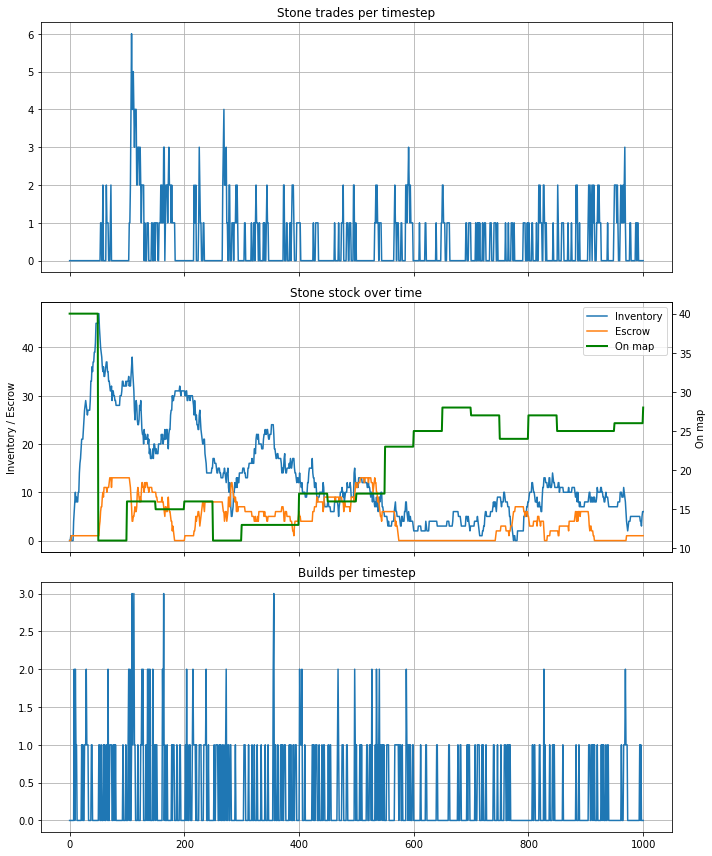

In [35]:
df_stone_t, df_stone_p, fig = plotting.diagnose_resource_market(dense_log0, resource="Stone", period=100)
df_stone_p

,tax_period,wood_trades,wood_inventory_total,wood_escrow_total,wood_on_map,builds
0,0,23,11.10,18.36,24.5,36.0
1,1,43,4.51,7.94,15.5,54.0
2,2,37,5.87,0.48,13.0,42.0
3,3,48,9.26,4.65,10.5,30.0
4,4,50,13.25,9.24,12.0,33.0
5,5,63,20.50,8.37,16.0,48.0
6,6,37,27.25,16.85,12.0,14.0
7,7,35,44.95,9.64,15.0,19.0
8,8,59,56.83,17.47,21.0,15.0
9,9,30,62.61,25.97,14.5,25.0


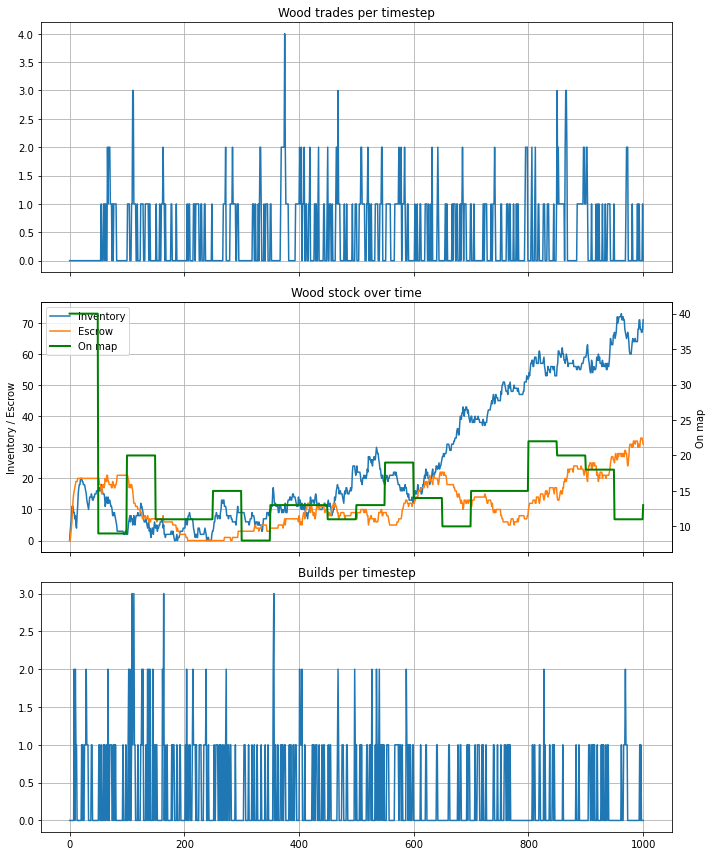

In [36]:
df_wood_t, df_wood_p, fig = plotting.diagnose_resource_market(dense_log0, resource="Wood", period=100)
df_wood_p

In [37]:
df_inv = plotting.inventory_table_by_tax_period(dense_log0, period=100, include_escrow=True)
df_inv

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,None,148.000000,0.0,1.0,3.0,4.0,0.0,151.000000,4.0,1.0
1,1,99,1,None,22.000000,0.0,11.0,6.0,3.0,1.0,28.000000,3.0,12.0
2,1,99,2,None,25.000000,2.0,0.0,0.0,5.0,0.0,25.000000,7.0,0.0
3,1,99,3,None,0.000000,0.0,4.0,0.0,0.0,2.0,0.000000,0.0,6.0
4,1,99,4,None,104.000000,0.0,2.0,5.0,4.0,1.0,109.000000,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,None,879.799375,3.0,0.0,8.0,5.0,1.0,887.799375,8.0,1.0
76,10,999,4,None,409.685938,26.0,0.0,7.0,4.0,0.0,416.685938,30.0,0.0
77,10,999,5,None,722.879688,1.0,2.0,12.0,5.0,0.0,734.879688,6.0,2.0
78,10,999,6,None,627.328438,4.0,0.0,21.0,4.0,0.0,648.328438,8.0,0.0


In [38]:
coin_pivot = df_inv.pivot(index="tax_day_number", columns="agent", values="coin_total")
coin_pivot

agent,0,1,2,3,4,5,6,7
tax_day_number,,,,,,,,
1,151.000000,28.000000,25.000000,0.000000,109.000000,50.000000,40.000000,16.000000
2,196.939062,162.035313,141.535313,191.490313,116.107500,204.337500,129.217500,155.337500
3,328.400937,182.397188,246.797188,202.404688,172.507500,306.637500,248.817500,235.037500
4,356.037812,225.160312,367.134063,382.667813,227.255625,335.698125,268.028125,261.018125
5,467.957500,269.896250,397.083750,489.062500,227.666875,400.754375,394.494375,332.084375
6,565.757187,341.987188,500.633438,647.622187,341.469375,475.826875,491.866875,502.836875
7,618.492500,393.951250,503.968750,670.587500,326.889375,599.686875,507.226875,530.196875
8,649.045000,412.923750,548.941250,668.090000,340.186250,599.595000,564.313750,739.905000
9,638.115625,425.316875,640.859375,656.708125,358.834688,703.073437,644.892187,741.199687


# comparison plots

In [39]:
def save_fig(fig, name, folder="figures_pdf"):
    import os
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{name}.pdf")
    fig.savefig(path, bbox_inches="tight", dpi=300)
    return path

In [40]:
def load_experiment_run(run_dir):
    import os, json, pickle

    with open(os.path.join(run_dir, "summary.json"), "r") as f:
        summary = json.load(f)

    dense_logs = None
    dense_log = None

    pkl_path = os.path.join(run_dir, "dense_logs_final.pkl")
    if os.path.exists(pkl_path):
        with open(pkl_path, "rb") as f:
            dense_logs = pickle.load(f)

        # keep old behavior too
        dense_log = dense_logs[0] if isinstance(dense_logs, dict) and 0 in dense_logs else None

    return {
        "run_dir": run_dir,
        "summary": summary,
        "dense_log": dense_log,
        "dense_logs": dense_logs,
    }

In [41]:
import os

BASE_RESULTS_DIR = "results"

selected_folders = [
    #"travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028", #base
    #"travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__base_lux_20260504_221734",
    #"travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__annealing_OG_20260512_213835",
    #"travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__final_base_20260514_150146",
    #"base_deep_20260519_203907",
    "base_short_v2_20260522_100839",

    #"travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade_20260501_163728",
    #"travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__trade_20260511_110634",
    #"trade_deep_20260519_222417",
    "trade_short_20260521_154655",

    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel_20260502_225247",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__high_travel_cost_20260507_102202",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__higher_travel_cost_20260508_172058",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__middle_cost_20260509_231304",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__10_14_cost_20260510_153929",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__10_12_20260511_110633",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__10_10_20260512_104944",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__correct_training_travel_20260513_170624", #10_10 with full phase 2
    #"travel_deep_10_12_20260519_222441",
    #"travel_10_8_short_20260521_154801",
    #"travel_5_5_short_20260522_113738",
    "travel_2_2_short_20260522_101641",
    #"travel_2_2_seed3_short_20260523_194023",

    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__fixed_tax_20260511_215738",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__fixed_new_20260512_154728",
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__correct_training_fixed_20260513_221000", #10_10 with full phase 2
    #"ttravel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__final_highlow_10_12_20260515_144759", should be good
    #"travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__final_luxUS_10_12_20260515_150524",
    #"travel_fixed_deep_10_12_20260519_222714",
    #"fixedtax_10_10_short_20260522_100809"
    #"fixed_2_2_short_20260523_202939",

    
    
]

run_dirs = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders
]



In [42]:

BASE_RESULTS_DIR = "results"

selected_folders_base = [

    "base_short_v2_20260522_100839",
    "base_seed2_short_20260526_104652",
    "base_seed3_short_20260525_141113",
       
]

run_dirs_base = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders_base
]

runs_base = plotting.load_experiment_runs(run_dirs_base)


In [43]:

BASE_RESULTS_DIR = "results"

selected_folders_trade = [

    "trade_short_20260521_154655",
    "trade_seed2_short_20260525_220709",
    "trade_seed3_short_20260525_220706",

]

run_dirs_trade = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders_trade
]

runs_trade = plotting.load_experiment_runs(run_dirs_trade)


In [44]:

BASE_RESULTS_DIR = "results"

selected_folders_travel = [

    "travel_2_2_short_20260522_101641",
    #"travel_2_2_seed2_short_20260525_140659",
    "travel_2_2_seed4_short_20260525_140605",
    "travel_2_2_seed3_short_20260523_194023",
       
]

run_dirs_travel = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders_travel
]

runs_travel = plotting.load_experiment_runs(run_dirs_travel)


In [45]:

BASE_RESULTS_DIR = "results"

selected_folders_fixed = [
    "fixed_2_2_short_20260523_202939",
    "fixed_seed2_short_20260525_140718",
    "fixed_seed3_short_20260525_220716",

]

run_dirs_fixed = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders_fixed
]

runs_fixed = plotting.load_experiment_runs(run_dirs_fixed)


In [46]:
import pickle
from pathlib import Path

run_dir = Path(run_dirs[0])

with open(run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

print(dense_logs.keys())
print(len(dense_logs))

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
20


In [47]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
if str(PROJECT_ROOT / "tutorials") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "tutorials"))

import simulation as exp

run_dir = Path(run_dirs[0])

with open(run_dir / "config.json", "r") as f:
    cfg = json.load(f)

env_obj_phase3b = exp.create_env(cfg["env_config_dict_phase3b"])


In [48]:
# def load_experiment_run(run_dir):
#     with open(os.path.join(run_dir, "summary.json"), "r") as f:
#         summary = json.load(f)

#     metrics = pd.read_csv(os.path.join(run_dir, "training_metrics.csv"))

#     with open(os.path.join(run_dir, "dense_logs_final.pkl"), "rb") as f:
#         dense_logs = pickle.load(f)

#     # choose one representative dense log for single-rollout plots
#     if isinstance(dense_logs, dict) and 0 in dense_logs:
#         dense_log = dense_logs[0]
#     else:
#         dense_log = dense_logs

#     return {
#         "run_dir": run_dir,
#         "name": summary.get("experiment_name", os.path.basename(run_dir)),
#         "summary": summary,
#         "metrics": metrics,
#         "dense_logs": dense_logs,   # all dense logs
#         "dense_log": dense_log,     # one example dense log
#     }
# def load_experiment_runs(run_dirs):
#     return [load_experiment_run(rd) for rd in run_dirs]

In [49]:
runs = plotting.load_experiment_runs(run_dirs)

In [50]:
runs_compare = plotting.combine_run_groups_for_comparison(
    runs_base,
    runs_trade,
    runs_travel,
    labels=["Base", "Trade", "Travel"],
)

'figures_pdf\\compare_training_curves_episode_reward_mean.pdf'

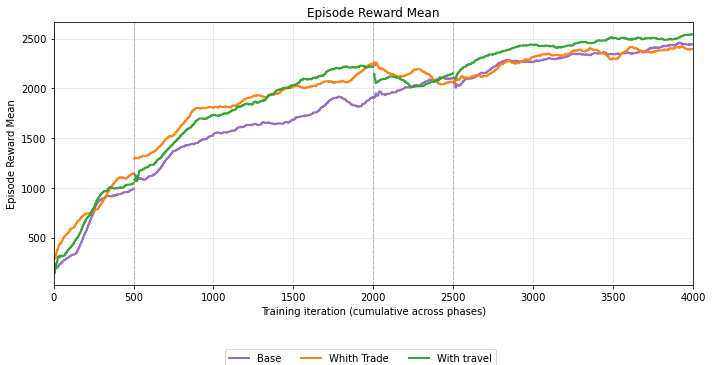

In [51]:
fig = plotting.compare_training_curves(
    runs_compare,
    metric="episode_reward_mean",
    short_labels=["Base", "Whith Trade", "With travel"],
    smooth_window=1,
    phase_boundary_iterations=(500, 2000, 2500),
)

save_fig(fig, "compare_training_curves_episode_reward_mean")

In [52]:
import importlib
importlib.reload(plotting)


<module 'utils.plotting' from 'c:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\utils\\plotting.py'>

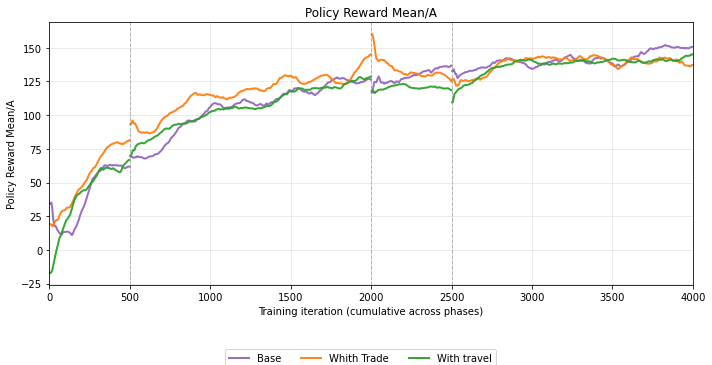

In [53]:
fig = plotting.compare_training_curves(
    runs,
    metric="policy_reward_mean/a",
    short_labels=["Base", "Whith Trade", "With travel"],
    smooth_window=10,
)

In [54]:
from pathlib import Path
import importlib
import tutorials.utils.plotting as plotting

importlib.reload(plotting)

<module 'tutorials.utils.plotting' from 'C:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\utils\\plotting.py'>

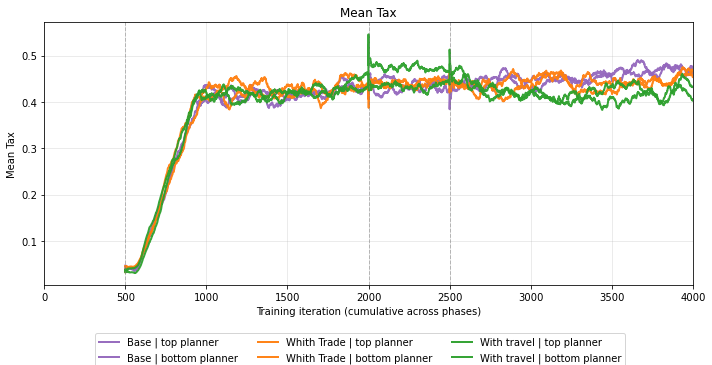

In [55]:
fig = plotting.compare_training_curves(
    runs,
    metric="mean_tax",
    short_labels=["Base", "Whith Trade", "With travel"],
    smooth_window=50,
)

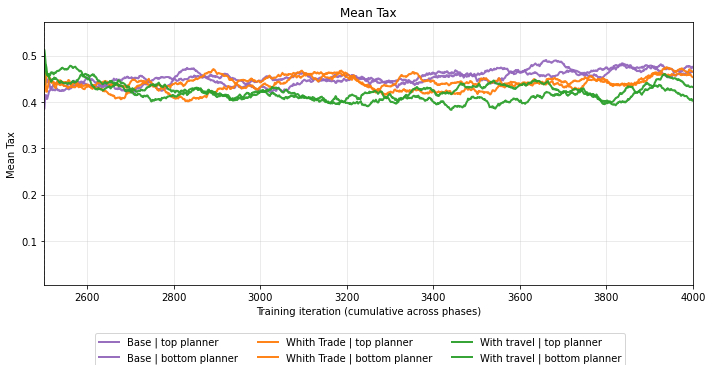

In [56]:
fig = plotting.compare_training_curves(
    runs,
    metric="mean_tax",
    short_labels=["Base", "Whith Trade", "With travel"],
    smooth_window=50,
    episode_range=(2500, 4000),
)


'figures_pdf\\plot_average_travel_count_runs_travel.pdf'

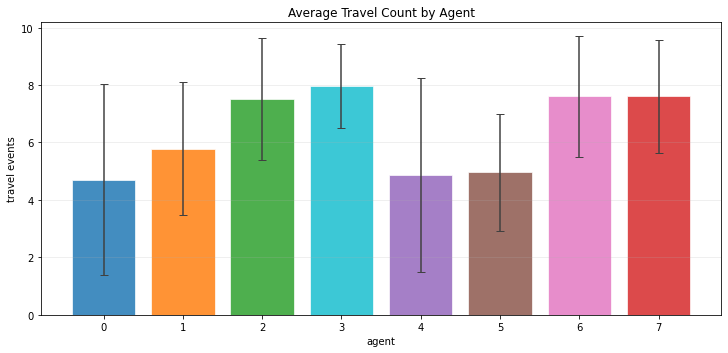

In [57]:
importlib.reload(plotting)
fig_travel_count, summary, raw = plotting.plot_average_travel_count(
    runs_travel,
    group_by="agent",  
)

save_fig(fig_travel_count, "plot_average_travel_count_runs_travel")

'figures_pdf\\plot_average_travel_count_runs_fixed.pdf'

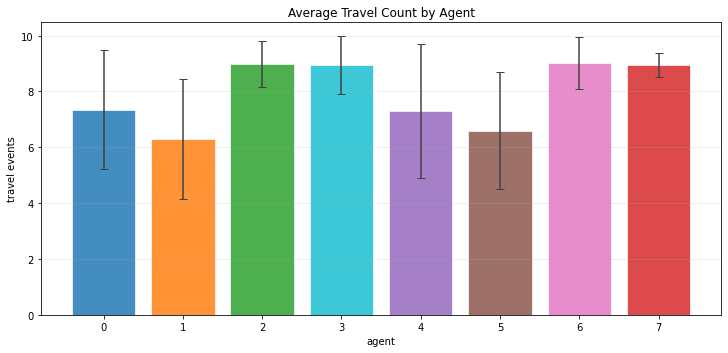

In [58]:

fig_travel_count, summary, raw = plotting.plot_average_travel_count(
    runs_fixed,
    group_by="agent",  
)

save_fig(fig_travel_count, "plot_average_travel_count_runs_fixed")

In [59]:
df = runs[1]["metrics"].copy()

zero_both = (df["mean_tax/p_top"] == 0) & (df["mean_tax/p_bottom"] == 0)
df.loc[zero_both, ["mean_tax/p_top", "mean_tax/p_bottom"]] = np.nan


In [60]:
run = runs[2]  

df = run["metrics"].copy()
df[["phase", "iter", "mean_tax/p_top", "mean_tax/p_bottom"]].iloc[1995:2008]


,phase,iter,mean_tax/p_top,mean_tax/p_bottom
1995,PHASE 2,1495,0.410000,0.474286
1996,PHASE 2,1496,0.412857,0.407143
1997,PHASE 2,1497,0.337143,0.417143
1998,PHASE 2,1498,0.390000,0.548571
1999,PHASE 2,1499,0.000000,0.000000
2000,PHASE 3A,0,0.461429,0.545714
2001,PHASE 3A,1,0.408571,0.411429
2002,PHASE 3A,2,0.404286,0.615714
2003,PHASE 3A,3,0.492857,0.415714
2004,PHASE 3A,4,0.000000,0.000000


In [61]:
df = runs[1]["metrics"].copy()

phase_change_rows = df.index[df["phase"].ne(df["phase"].shift())].tolist()
phase_change_rows

for i in phase_change_rows:
    print("\n--- boundary row", i, "---")
    display(df[["phase", "iter", "mean_tax/p_top", "mean_tax/p_bottom"]].iloc[max(0, i-5):i+8])
config = runs[0]["config"]

config.keys()



--- boundary row 0 ---


,phase,iter,mean_tax/p_top,mean_tax/p_bottom
0,PHASE 1,0,0.0,0.0
1,PHASE 1,1,0.0,0.0
2,PHASE 1,2,0.0,0.0
3,PHASE 1,3,0.0,0.0
4,PHASE 1,4,0.0,0.0
5,PHASE 1,5,0.0,0.0
6,PHASE 1,6,0.0,0.0
7,PHASE 1,7,0.0,0.0



--- boundary row 500 ---


,phase,iter,mean_tax/p_top,mean_tax/p_bottom
495,PHASE 1,495,0.000000,0.000000
496,PHASE 1,496,0.000000,0.000000
497,PHASE 1,497,0.000000,0.000000
498,PHASE 1,498,0.000000,0.000000
499,PHASE 1,499,0.000000,0.000000
500,PHASE 2,0,0.045714,0.032857
501,PHASE 2,1,0.042857,0.041429
502,PHASE 2,2,0.048571,0.051429
503,PHASE 2,3,0.041429,0.045714
504,PHASE 2,4,0.000000,0.000000



--- boundary row 2000 ---


,phase,iter,mean_tax/p_top,mean_tax/p_bottom
1995,PHASE 2,1495,0.450000,0.352857
1996,PHASE 2,1496,0.501429,0.470000
1997,PHASE 2,1497,0.497143,0.442857
1998,PHASE 2,1498,0.458571,0.464286
1999,PHASE 2,1499,0.000000,0.000000
2000,PHASE 3A,0,0.405714,0.407143
2001,PHASE 3A,1,0.415714,0.367143
2002,PHASE 3A,2,0.478571,0.455714
2003,PHASE 3A,3,0.417143,0.477143
2004,PHASE 3A,4,0.000000,0.000000



--- boundary row 2500 ---


,phase,iter,mean_tax/p_top,mean_tax/p_bottom
2495,PHASE 3A,495,0.411429,0.461429
2496,PHASE 3A,496,0.402857,0.458571
2497,PHASE 3A,497,0.428571,0.454286
2498,PHASE 3A,498,0.451429,0.462857
2499,PHASE 3A,499,0.000000,0.000000
2500,PHASE 3B,0,0.420000,0.462857
2501,PHASE 3B,1,0.442857,0.418571
2502,PHASE 3B,2,0.454286,0.435714
2503,PHASE 3B,3,0.440000,0.435714
2504,PHASE 3B,4,0.000000,0.000000


dict_keys(['framework', 'phase1_iters', 'phase2_iters', 'phase3a_iters', 'phase3b_iters', 'num_workers', 'num_envs_per_worker', 'num_gpus', 'num_cpus_per_worker', 'rollout_fragment_length', 'train_batch_size', 'sgd_minibatch_size', 'num_sgd_iter', 'min_band', 'period', 'episode_length', 'world_size', 'layout_file', 'save_results', 'results_dir', 'restrict_trade_to_region', 'travel_enabled_phase1', 'travel_enabled_phase2', 'travel_enabled_phase3a', 'travel_enabled_phase3b', 'travel_cost_coin_phase1', 'travel_cost_labor_phase1', 'travel_cooldown_phase1', 'travel_cost_coin_phase2', 'travel_cost_labor_phase2', 'travel_cooldown_phase2', 'travel_cost_coin_phase3a', 'travel_cost_labor_phase3a', 'travel_cooldown_phase3a', 'travel_cost_coin_phase3b', 'travel_cost_labor_phase3b', 'travel_cooldown_phase3b', 'fixed_tax_planner_id', 'fixed_tax_bracket_rates', 'fixed_tax_bracket_rates_top', 'fixed_tax_bracket_rates_bottom', 'experiment_extra_tag', 'experiment_name', 'env_config_dict_phase1', 'env_co

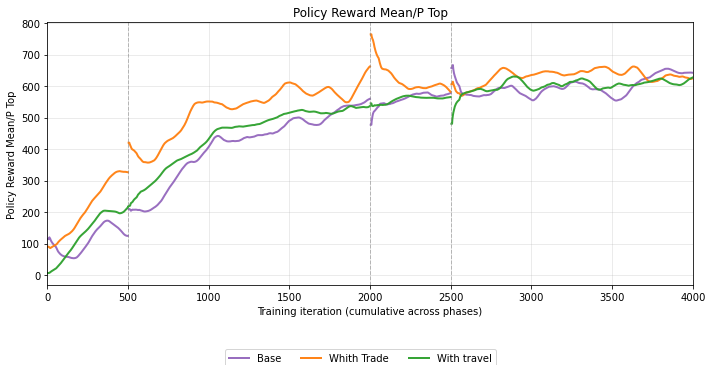

In [62]:
fig = plotting.compare_training_curves(
    runs,
    metric="policy_reward_mean/p_top",
    short_labels=["Base", "Whith Trade", "With travel"],
    smooth_window=50,
)


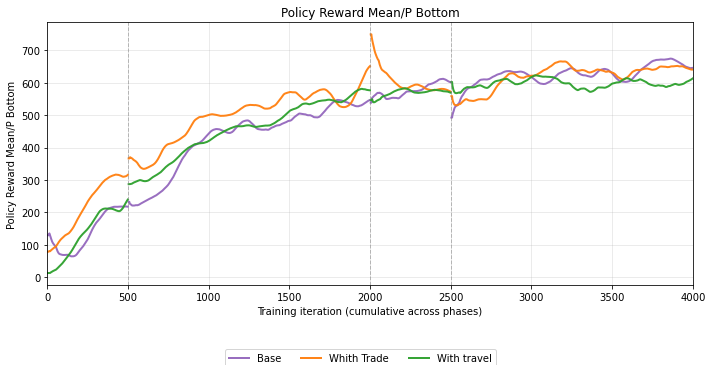

In [63]:
fig = plotting.compare_training_curves(
    runs,
    metric="policy_reward_mean/p_bottom",
    short_labels=["Base", "Whith Trade", "With travel"],
    smooth_window=50,
)

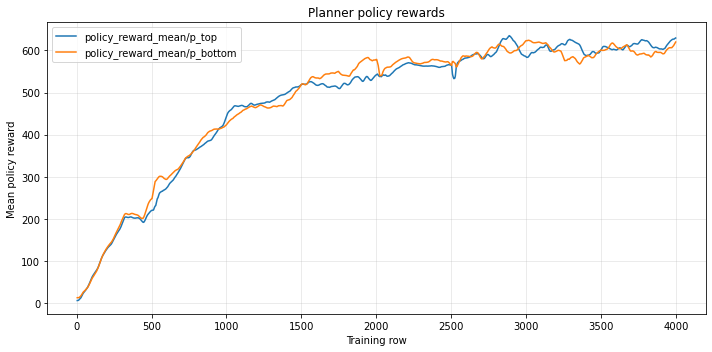

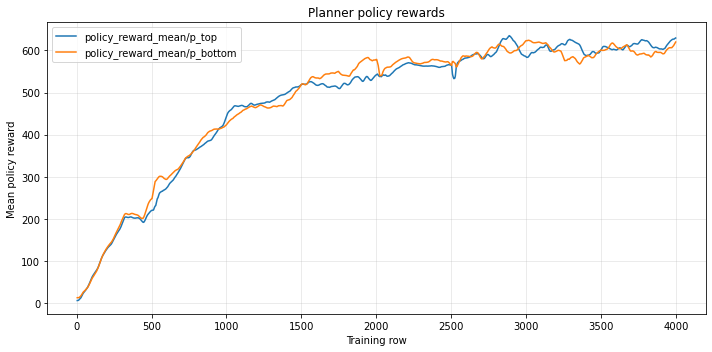

In [64]:
plotting.plot_planner_rewards(runs[2])

,label,group,group_member,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,,,
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__fixedtax_10_10_short,Base,Base,1,909.00,218.289454,280.49750,1794,378,7272.0,0,4,4,travel-off__regionaltrade-on__layout-stacked_5...,500,1500,500,1500
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__trade_short,Whith Trade,Whith Trade,1,920.80,159.944473,326.02125,1573,416,7511.0,0,4,4,travel-off__regionaltrade-off__layout-stacked_...,500,1500,500,1500
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__travel_5_5_short,With travel,With travel,1,825.15,227.823303,313.97000,1417,356,6773.0,27,3,5,travel-on__regionaltrade-off__layout-stacked_5...,500,1500,500,1500


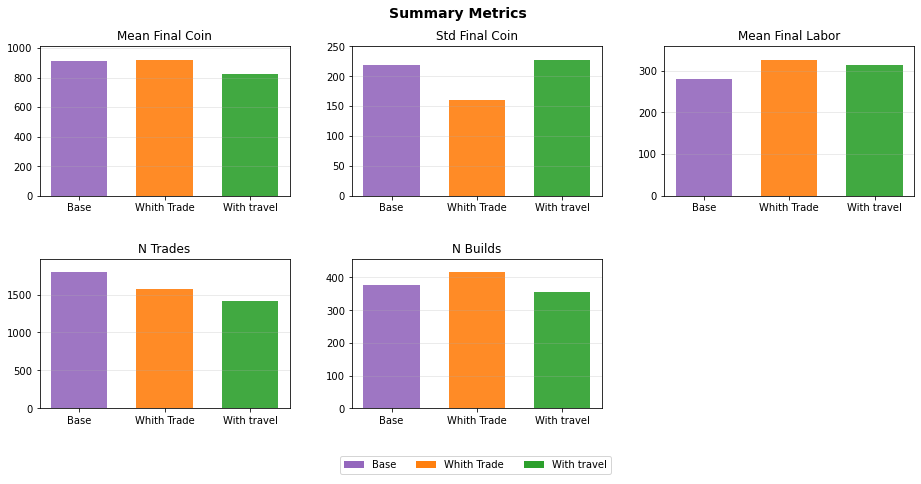

In [65]:
fig_single, out_single = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar=None,  
)

out_single

In [66]:
import importlib
import tutorials.utils.plotting as plotting
importlib.reload(plotting)


<module 'tutorials.utils.plotting' from 'C:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\utils\\plotting.py'>

In [67]:
runs_compare = plotting.combine_run_groups_for_comparison(
    runs_base,
    runs_trade,
    runs_travel,
    labels=["Base", "Trade", "Travel"],
)


'figures_pdf\\compare_summary_bars.pdf'

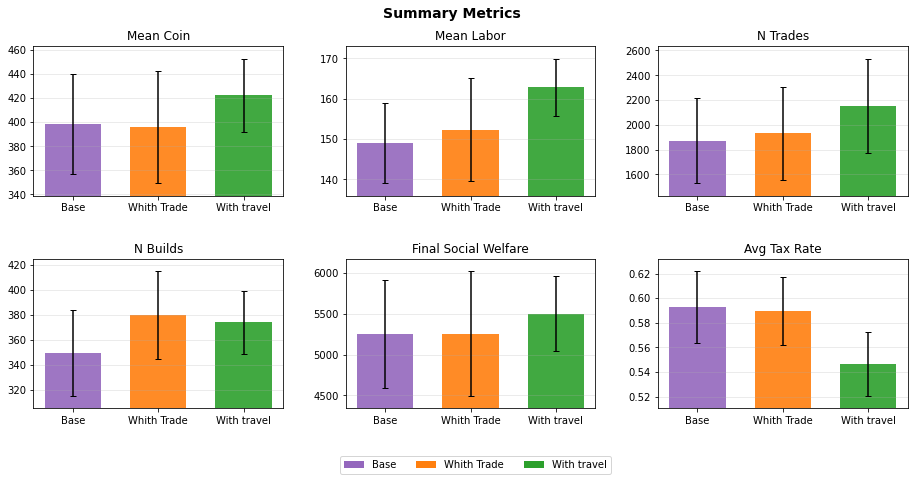

In [68]:
fig_avg, out_avg = plotting.compare_summary_bars(
    runs_compare,
    metrics=[
        "mean_coin",
        "mean_labor",
        "n_trades",
        "n_builds",
        "final_social_welfare",
        "avg_tax_rate",
    ],
    short_labels=["Base", "Whith Trade", "With travel"],
    env_obj=env_obj_phase3b,
    show_legend=True,
    errorbar="std",
    start_y_at_zero=False,  
    show_group_members=False,
)

out_avg

save_fig(fig_avg, "compare_summary_bars")

'figures_pdf\\compare_summary_bars_show_group_members.pdf'

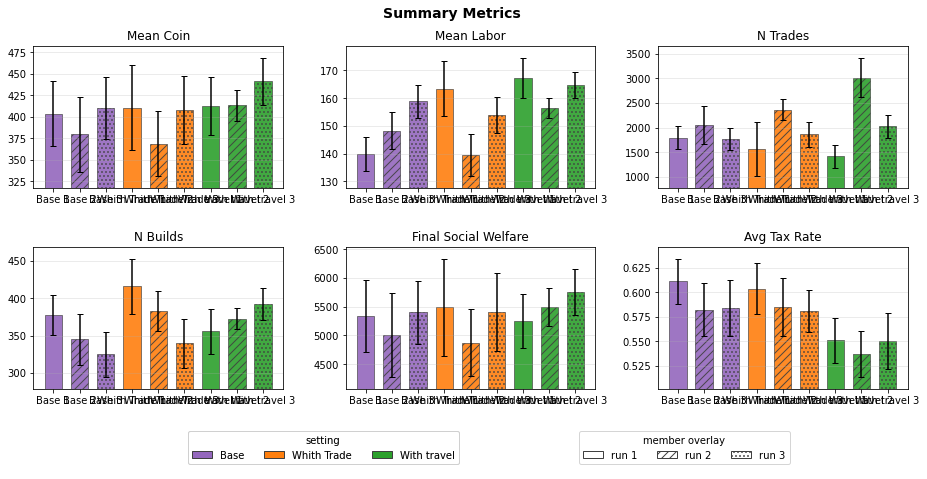

In [69]:
fig_avg, out_avg = plotting.compare_summary_bars(
    runs_compare,
    metrics=[
        "mean_coin",
        "mean_labor",
        "n_trades",
        "n_builds",
        "final_social_welfare",
        "avg_tax_rate",
    ],
    short_labels=["Base", "Whith Trade", "With travel"],
    env_obj=env_obj_phase3b,
    show_legend=True,
    errorbar="std",
    start_y_at_zero=False,  
    show_group_members=True,
)

out_avg

save_fig(fig_avg, "compare_summary_bars_show_group_members")

'figures_pdf\\compare_summary_bars_percent_change_from_baseline.pdf'

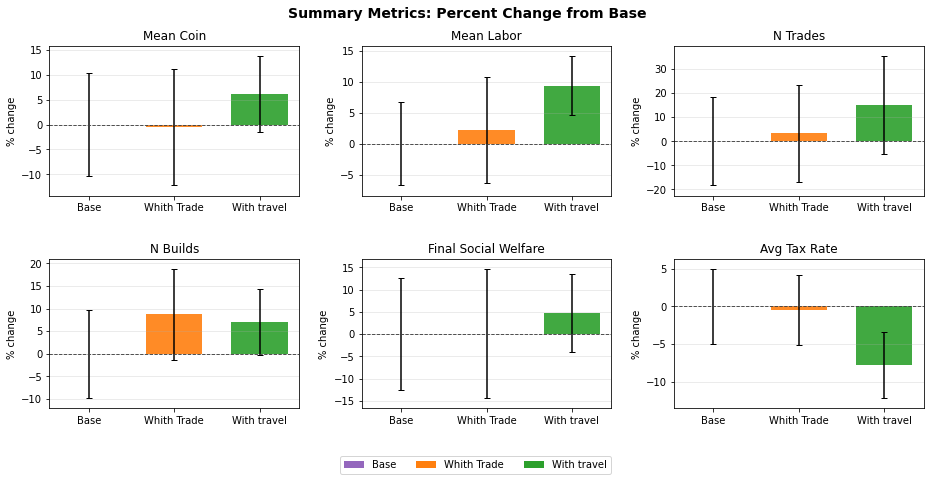

In [70]:
fig_avg, df = plotting.compare_summary_bars(
    runs_compare,
    short_labels=["Base", "Whith Trade", "With travel"],
     metrics=[
        "mean_coin",
        "mean_labor",
        "n_trades",
        "n_builds",
        "final_social_welfare",
        "avg_tax_rate",
    ],
    env_obj=env_obj_phase3b,
    percent_change_from_baseline=True,
)

save_fig(fig_avg, "compare_summary_bars_percent_change_from_baseline")


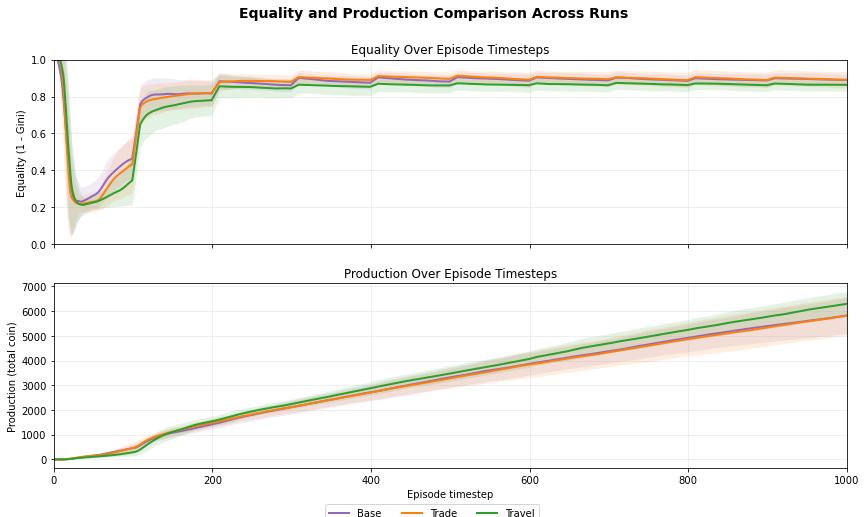

In [71]:
importlib.reload(plotting)
fig, summary_df, raw_df = plotting.compare_equality_production_over_time(
    runs_compare,
    short_labels=["Base", "Trade", "Travel"],  # optional
    show_std=True,
    smooth_window=10,
    max_timestep=1000,
)


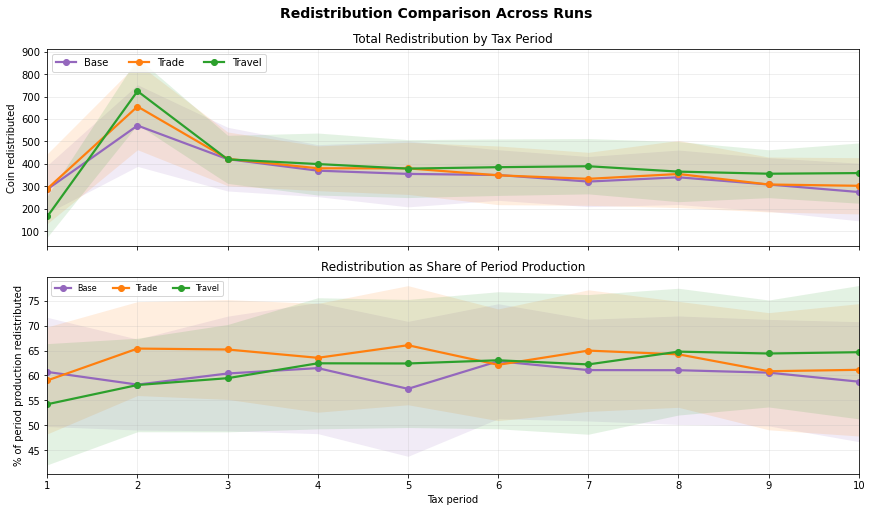

In [72]:
fig, summary_df, raw_df = plotting.compare_redistribution_over_time(
    runs_compare,
    short_labels=["Base", "Trade", "Travel"],  # optional
    period=100,
    show_std=True,
    smooth_window=1,
)


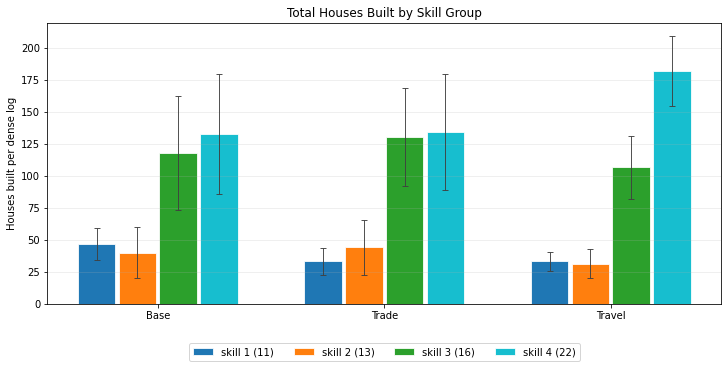

In [73]:
importlib.reload(plotting)
fig, summary_df, raw_df = plotting.compare_builds_by_skill(
    runs_compare,
    short_labels=["Base", "Trade", "Travel"],  # optional
    show_std=True,
)


'figures_pdf\\compare_skill_group_mechanisms.pdf'

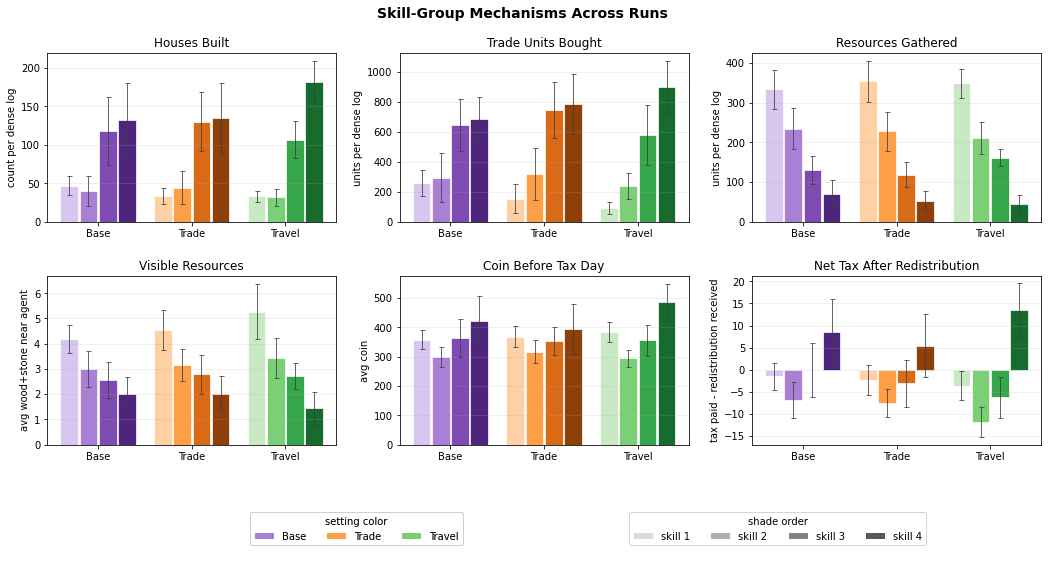

In [74]:

fig_avg_skill, summary_df, raw_df = plotting.compare_skill_group_mechanisms(
    runs_compare,
    short_labels=["Base", "Trade", "Travel"],
    period=100,
    rate_disc=0.05,
    visible_radius=5,
    show_std=True,
)

save_fig(fig_avg_skill, "compare_skill_group_mechanisms")

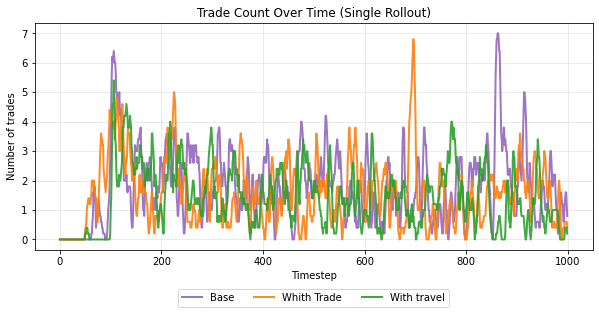

In [75]:
fig_single = plotting.compare_trade_dynamics(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    mode="single",
    smooth_window=5,  
)

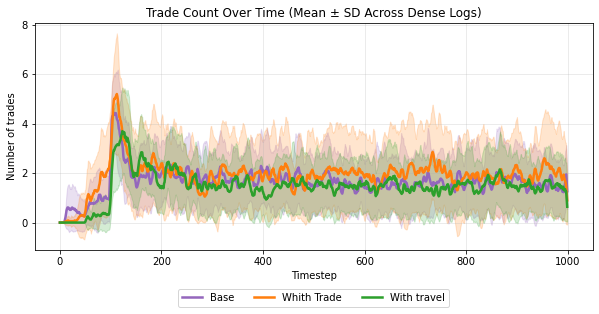

In [76]:
fig_avg = plotting.compare_trade_dynamics(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    mode="average",
    smooth_window=5,
)

,label,gini,error,n_dense_logs
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__fixedtax_10_10_short,Base,0.122590,NaN,1
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__trade_short,Whith Trade,0.096691,NaN,1
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__travel_5_5_short,With travel,0.143264,NaN,1


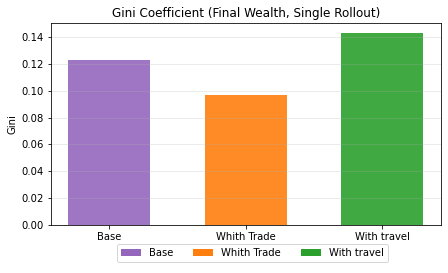

In [77]:
fig_single, out_single = plotting.compare_gini(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    mode="single",
    errorbar=None,
)

out_single

,label,gini,error,n_dense_logs
travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__fixedtax_10_10_short,Base,0.092404,0.025664,20
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__trade_short,Whith Trade,0.091493,0.049493,20
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__travel_5_5_short,With travel,0.136355,0.035345,20


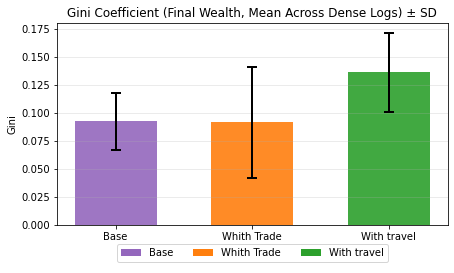

In [78]:
fig_avg, out_avg = plotting.compare_gini(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    mode="average",
    errorbar="std",
)

out_avg

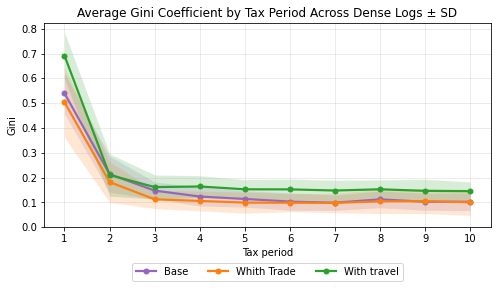

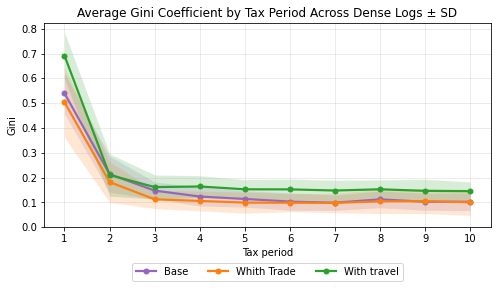

In [79]:
import importlib
importlib.reload(plotting)

runs = plotting.load_experiment_runs(run_dirs)

fig_gini_periods, gini_periods, gini_periods_raw = plotting.compare_gini_over_tax_periods(
    runs,
    short_labels=["Base", "Whith Trade", "With travel"],
    period=100,
    max_periods=10,
    errorbar="std",
    show_legend=True,
)

#gini_periods
fig_gini_periods



c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\numpy\lib\nanfunctions.py:1671: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\numpy\lib\nanfunctions.py:1671: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)


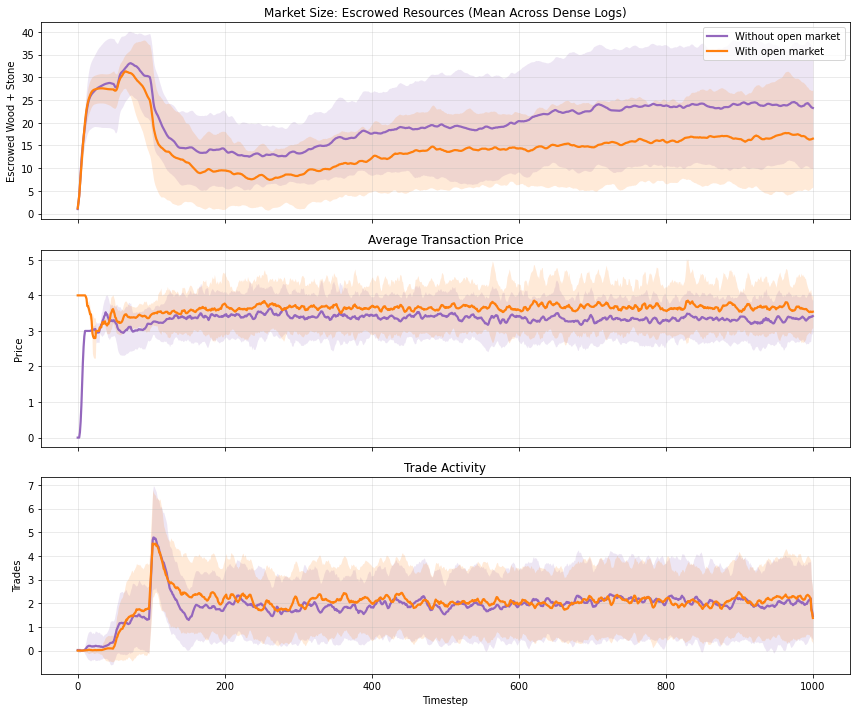

In [80]:
fig_market_open, df_market_open = plotting.compare_market_size_prices_trade_activity(
    runs_compare[:2],
    short_labels=["Without open market", "With open market"],
    resources=("Wood", "Stone"),
    mode="average",
    smooth_window=5,
    show_std=True,
)

 

C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\utils\plotting.py:5131: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  fig_redist.subplots_adjust(top=0.78)


'figures_pdf\\trade_mechanics_and_redistribution.pdf'

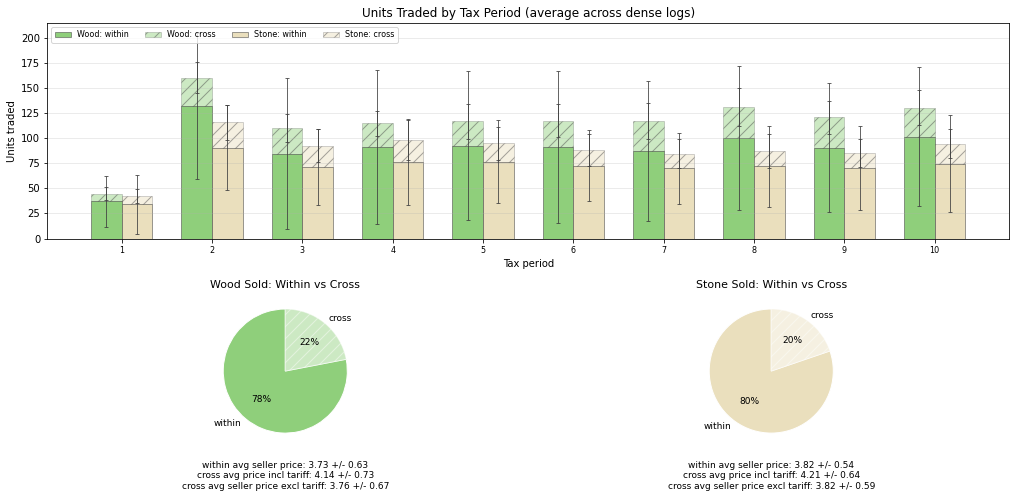

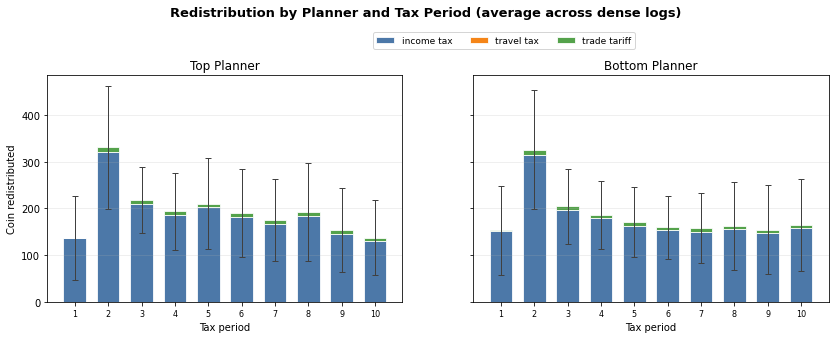

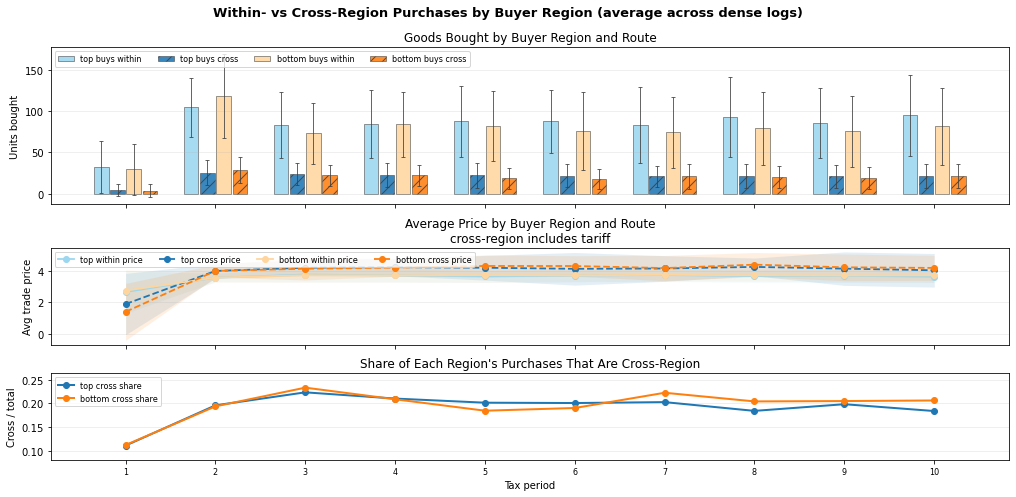

In [81]:
fig, trade_units, price_summary, redist = plotting.plot_trade_enabled_run_trade_and_redistribution(
    runs_trade,
    mode="average",
    show_std=True,
)

save_fig(fig, "trade_mechanics_and_redistribution")

C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\utils\plotting.py:5131: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  fig_redist.subplots_adjust(top=0.78)


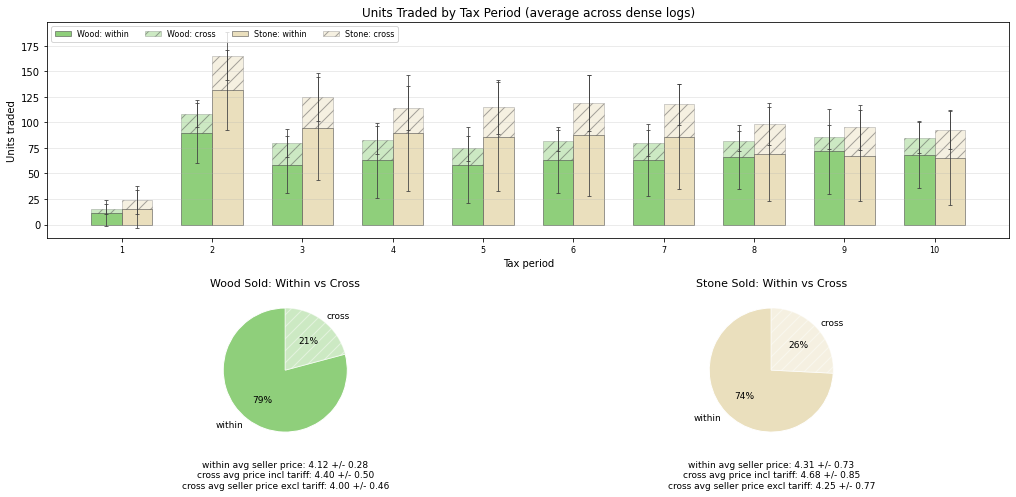

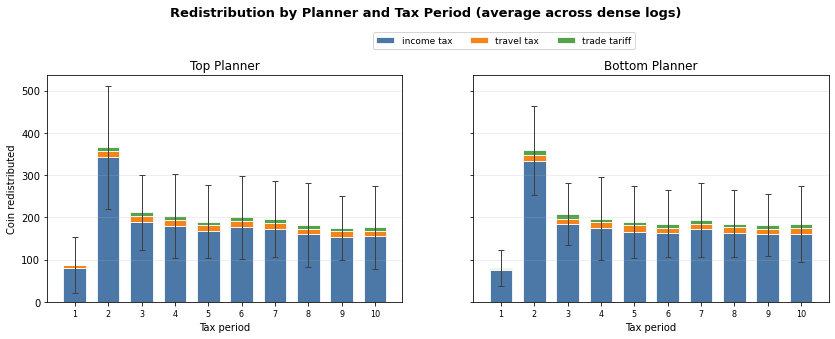

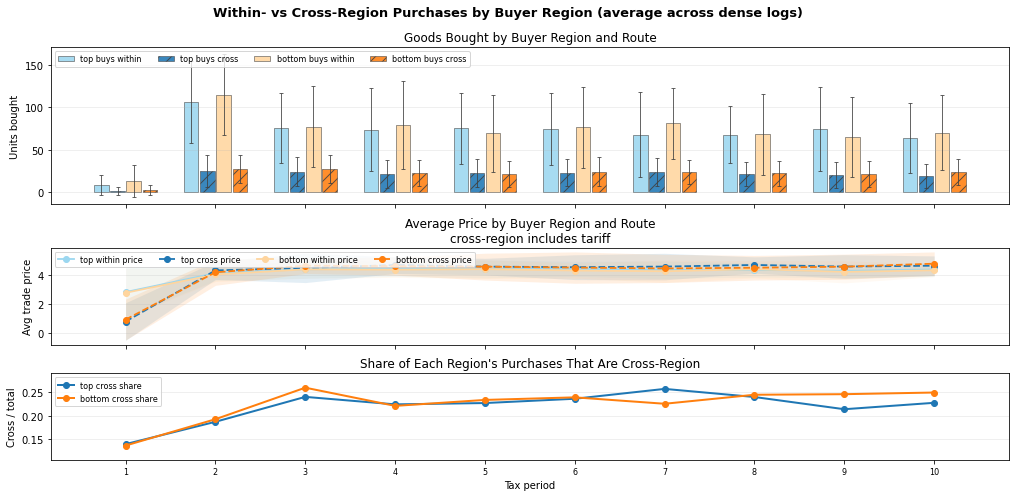

In [82]:
fig, trade_units, price_summary, redist = plotting.plot_trade_enabled_run_trade_and_redistribution(
    runs_travel,
    mode="average",
    show_std=True,
)

'figures_pdf\\plot_periodic_tax_streams_runs_fixed.pdf'

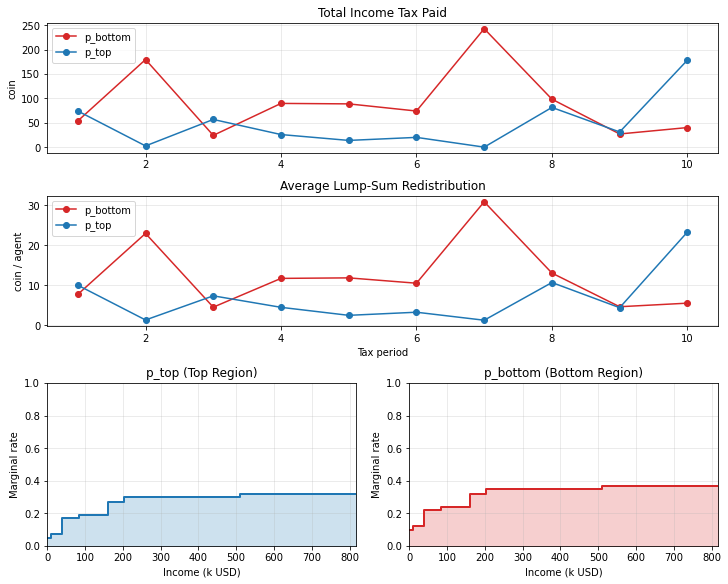

In [83]:
from pathlib import Path
import importlib
import tutorials.utils.plotting as plotting

importlib.reload(plotting)

#result_dir = r"C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\results\travel_fixed_deep_10_12_20260519_222714"


fig, df_tax, dense_log, dense_logs = plotting.plot_periodic_tax_streams_from_result_folder(
    runs_fixed,
    episode_key=0,
)

save_fig(fig, "plot_periodic_tax_streams_runs_fixed")

In [84]:
usd_scaling = 1000
eu_scaling = 1000 # 850 if in dolars

brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

# brackets = np.array([
#     0,
#     13200,
#     22050,
#     31100,
#     40300,
#     51750,
#     234850
# ]) / eu_scaling

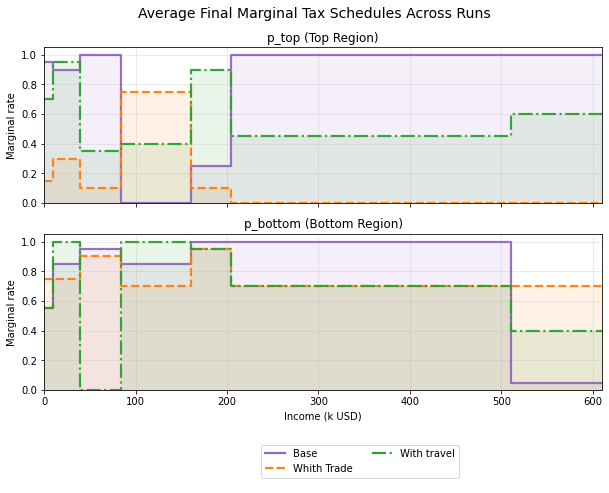

In [85]:
runs_single = []
for r in runs:
    r_copy = r.copy()
    r_copy["dense_logs"] = {0: r["dense_log"]}  # only one log
    runs_single.append(r_copy)

fig_single, out_single = plotting.compare_avg_final_tax_schedules_two_planners(
    runs_single,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar=None,  
    last_bin_width=100,
)

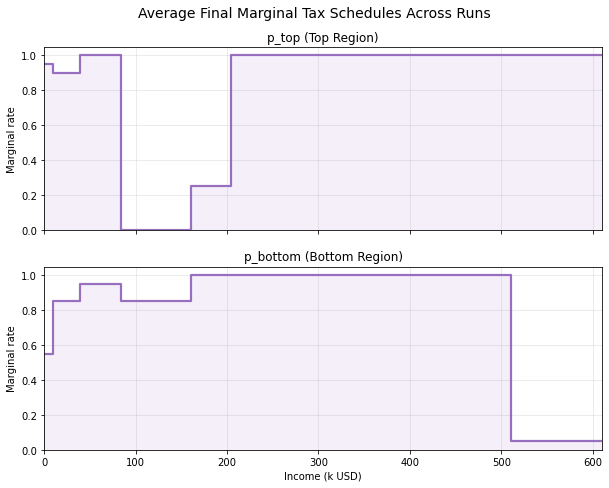

In [86]:
runs_single_no_compare = []

r_copy = runs[0].copy()
r_copy["dense_logs"] = {0: runs[0]["dense_log"]}
runs_single_no_compare.append(r_copy)

fig_single, out_single = plotting.compare_avg_final_tax_schedules_two_planners(
    runs_single_no_compare,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    #short_labels=["No travel"],
    show_legend=False,
    errorbar=None,
    last_bin_width=100,
)

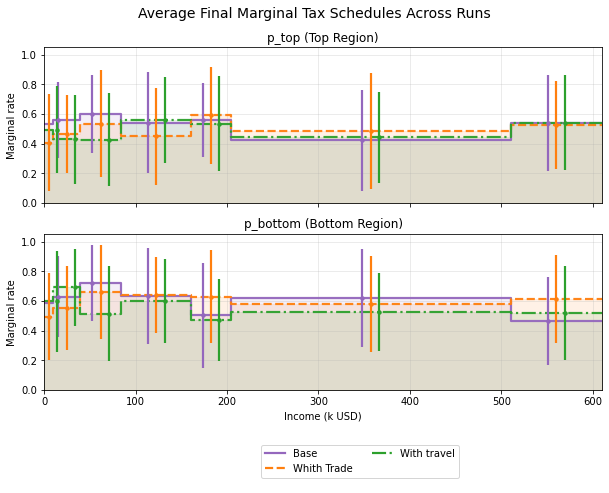

In [87]:
fig_avg, out_avg = plotting.compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    show_legend=True,
    errorbar="std",  
    last_bin_width=100,
)


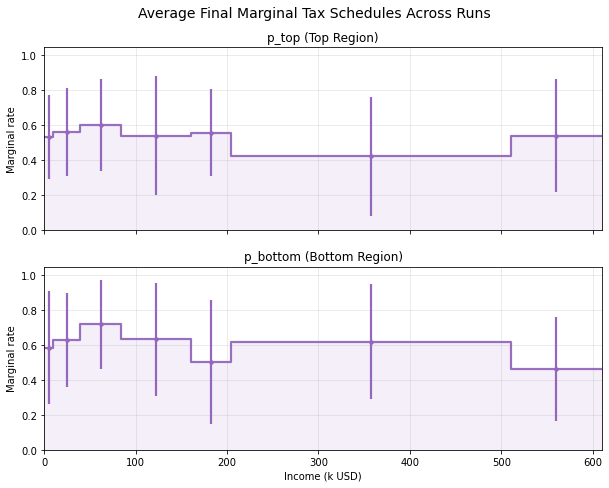

In [88]:
fig_avg, out_avg = plotting.compare_avg_final_tax_schedules_two_planners(
    [runs[0]],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    show_legend=False,
    errorbar="std",  
    last_bin_width=100,
)

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from simulation import get_disc_rates

def plot_individual_final_tax_schedules(
    runs,
    env_obj,
    brackets,
    selected=None,          # None = all dense logs; or [(run_idx, log_key), ...]
    top_first=True,
    short_labels=None,
    last_bin_width=100,
    figsize=(10, 7),
):
    disc_rates = get_disc_rates(env_obj)
    brackets = np.asarray(brackets, dtype=float)

    right_edge = brackets[-1] + last_bin_width
    step_x = np.append(brackets, right_edge)

    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    def extract_logs(run):
        if "dense_logs" in run:
            obj = run["dense_logs"]
        elif "dense_log" in run:
            obj = {0: run["dense_log"]}
        else:
            return {}

        if isinstance(obj, dict):
            return obj
        if isinstance(obj, list):
            return {i: log for i, log in enumerate(obj)}
        return {}

    def split_last(arr):
        last = np.asarray(arr)[-1]
        half = last.shape[0] // 2
        if top_first:
            return last[:half], last[half:]
        else:
            return last[half:], last[:half]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    plot_i = 0

    for run_idx, run in enumerate(runs):
        logs = extract_logs(run)

        run_label = (
            short_labels[run_idx]
            if short_labels is not None
            else run.get("name", f"run {run_idx}")
        )

        for log_key, dense_log in logs.items():
            if selected is not None and (run_idx, log_key) not in selected:
                continue

            planner_actions = dense_log["planner_actions"]

            top_actions, _ = split_last(planner_actions["p_top"])
            _, bottom_actions = split_last(planner_actions["p_bottom"])

            top_rates = disc_rates[np.clip(top_actions.astype(int), 0, len(disc_rates) - 1)]
            bottom_rates = disc_rates[np.clip(bottom_actions.astype(int), 0, len(disc_rates) - 1)]

            top_step_y = np.append(top_rates, top_rates[-1])
            bottom_step_y = np.append(bottom_rates, bottom_rates[-1])

            color = colors[plot_i % len(colors)]
            label = f"{run_label}, log {log_key}"

            axes[0].step(step_x, top_step_y, where="post", color=color, linewidth=1.8, label=label)
            axes[1].step(step_x, bottom_step_y, where="post", color=color, linewidth=1.8, label=label)

            plot_i += 1

    axes[0].set_title("p_top final tax schedules")
    axes[0].set_ylabel("Marginal rate")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("p_bottom final tax schedules")
    axes[1].set_xlabel("Income")
    axes[1].set_ylabel("Marginal rate")
    axes[1].grid(True, alpha=0.3)

    axes[1].set_xlim(brackets[0], right_edge)

    fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=2, fontsize=9)
    fig.subplots_adjust(bottom=0.22, top=0.92)

    return fig
 

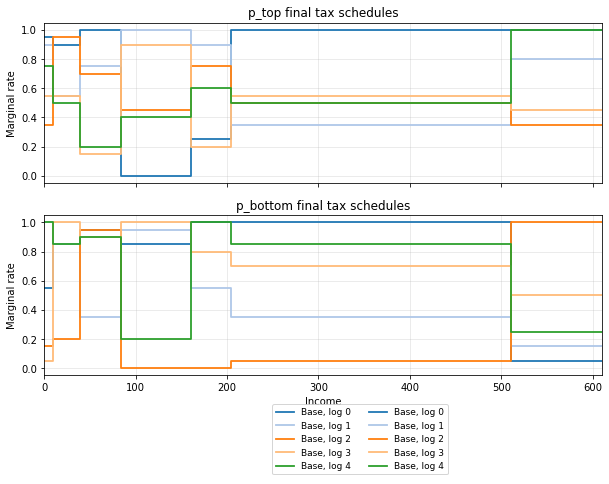

In [90]:
fig = plot_individual_final_tax_schedules(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[
        (0, 0),   # run 0, dense log key 0
        (0, 1),   # run 0, dense log key 1
        (0, 2),   # run 0, dense log key 2
        (0, 3),   # run 0, dense log key 3
        (0, 4),   # run 0, dense log key 4
    ],
    top_first=True,
    short_labels=["Base", "Whith Trade", "With travel"],
    last_bin_width=100,
)


In [91]:
# fig = plot_individual_final_tax_schedules(
#     runs,
#     env_obj=env_obj_phase3b,
#     brackets=brackets,
#     top_first=True,
#     short_labels=["Base", "Whith Trade", "With travel"],
#     last_bin_width=100,
# )


# Effect on travel

c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\matplotlib\cbook\__init__.py:1376: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\matplotlib\cbook\__init__.py:1376: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\matplotlib\cbook\__init__.py:1376: VisibleDeprecationWarning: Crea

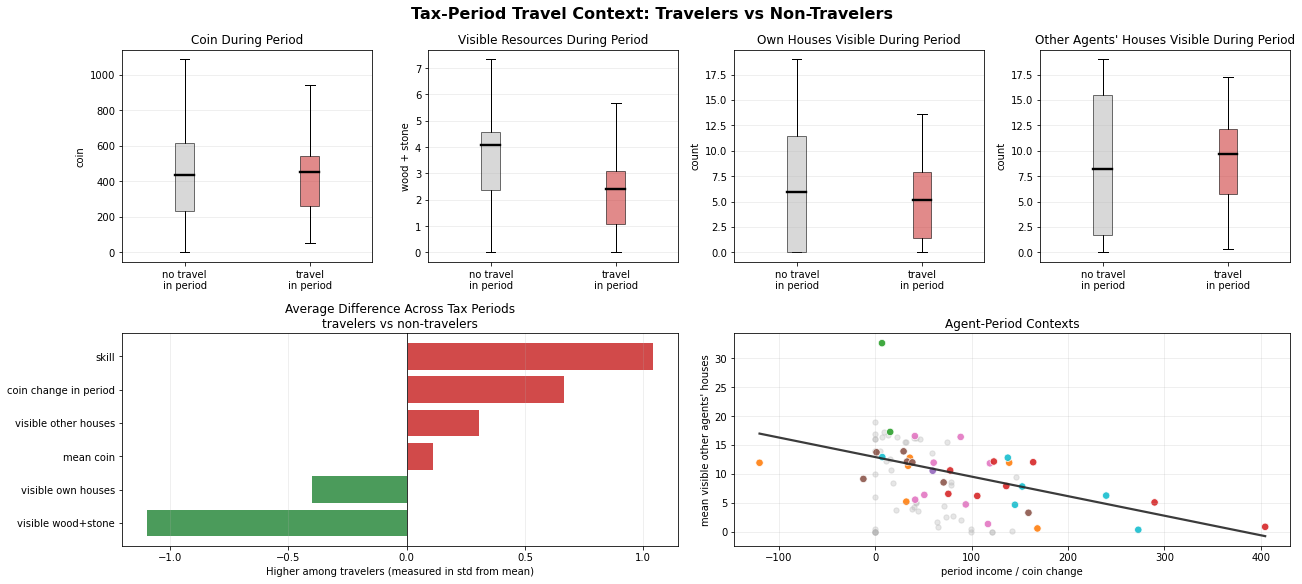

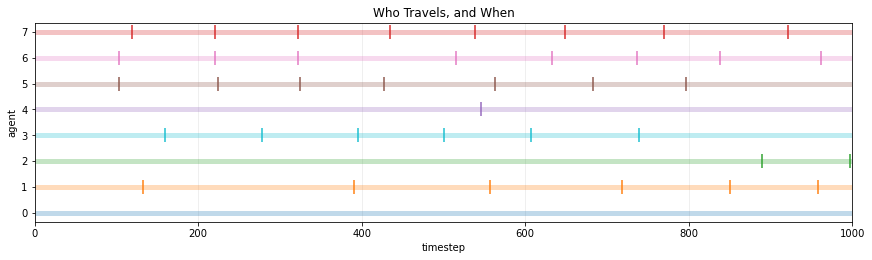

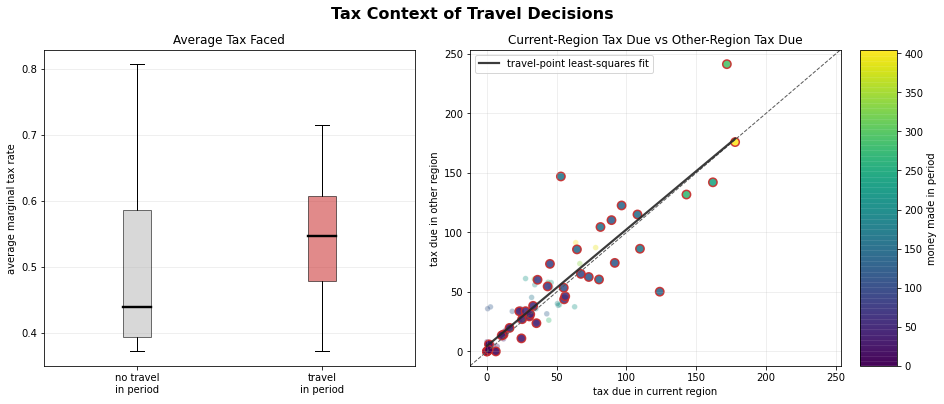

In [92]:
import importlib
import tutorials.utils.plotting as plotting
importlib.reload(plotting)

log = plotting._extract_logs_from_run(runs[2])[5]

fig, period_df = plotting.plot_tax_period_travel_context_dashboard(
    log,
    period=100,
    visible_radius=5,
    income_window=100,
    figsize=(18, 13),
)

fig_timeline = plotting.plot_travel_timeline_by_agent(log)

fig_tax, tax_df = plotting.plot_tax_travel_counterfactuals(
    log,
    period=100,
    visible_radius=5,
    income_window=100,
)

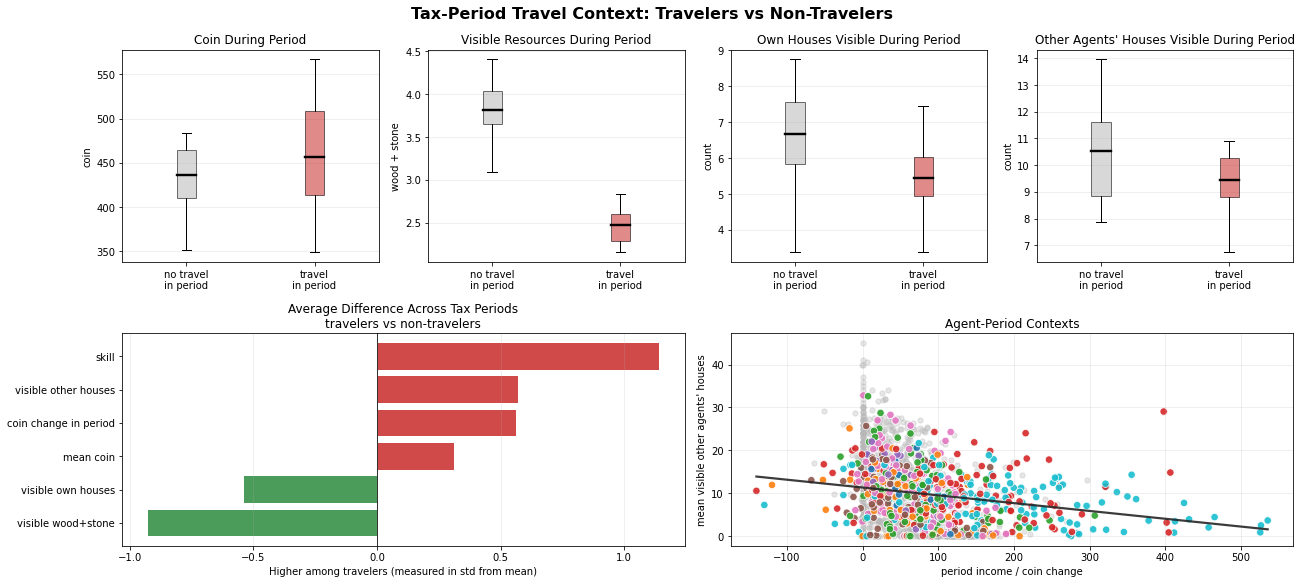

In [93]:
importlib.reload(plotting)
fig, period_df = plotting.plot_tax_period_travel_context_dashboard(runs[2])


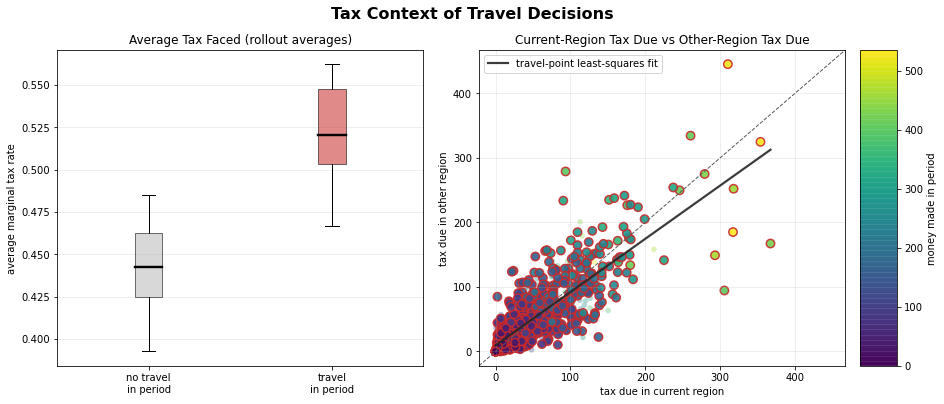

In [94]:
importlib.reload(plotting)
fig, tax_df = plotting.plot_tax_travel_counterfactuals(runs[2])


'figures_pdf\\plot_tax_period_travel_combined_dashboard.pdf'

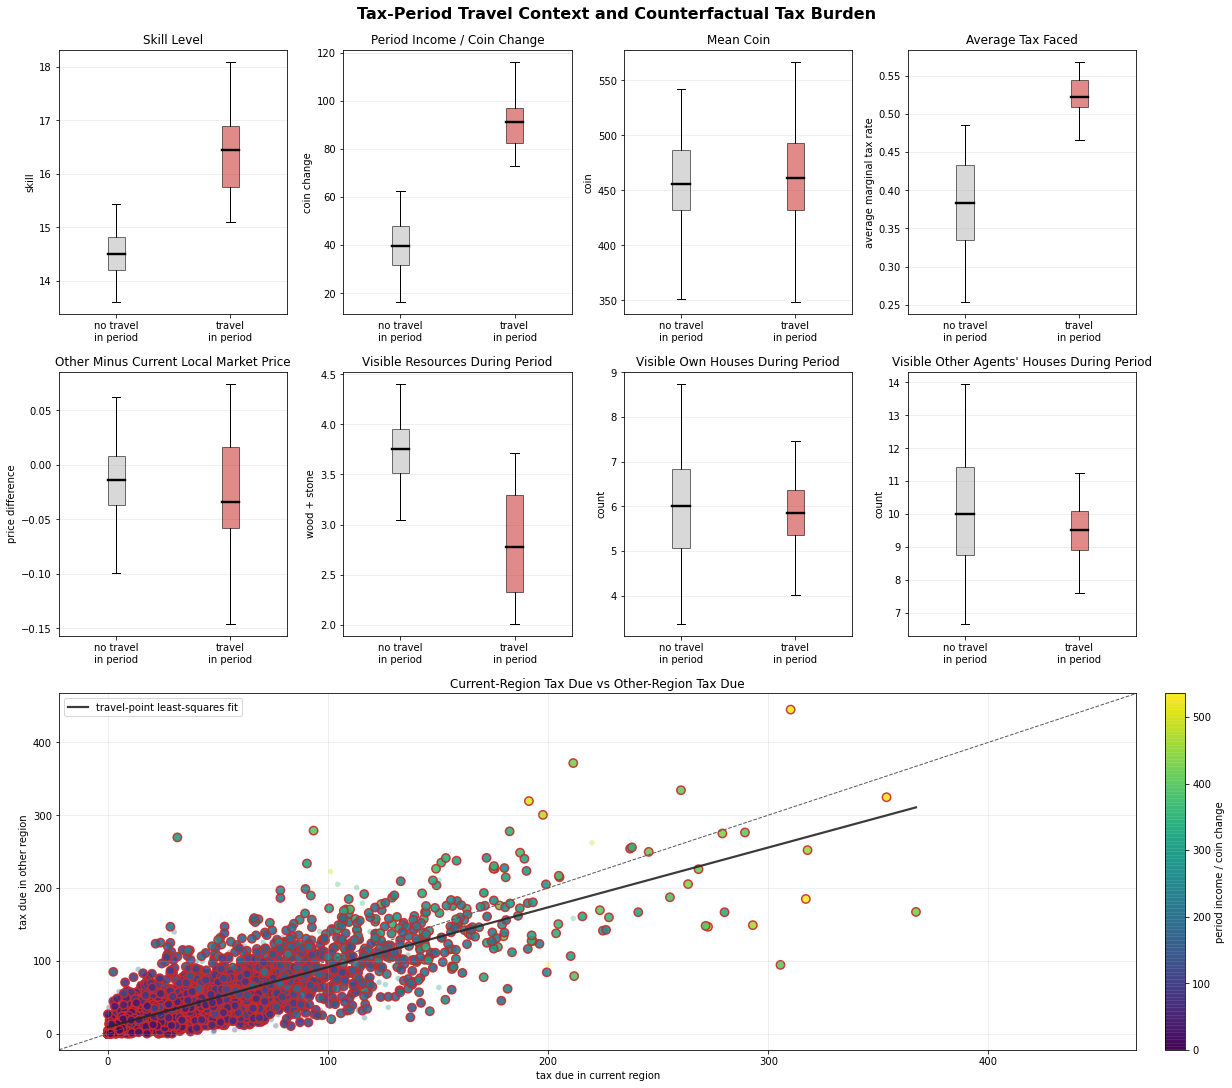

In [95]:
importlib.reload(plotting)
fig, combined_df, smd_df = plotting.plot_tax_period_travel_combined_dashboard(
    runs_travel,
    period=100,
    visible_radius=5,
    income_window=100,
    rate_disc=0.05,
)

save_fig(fig, "plot_tax_period_travel_combined_dashboard")

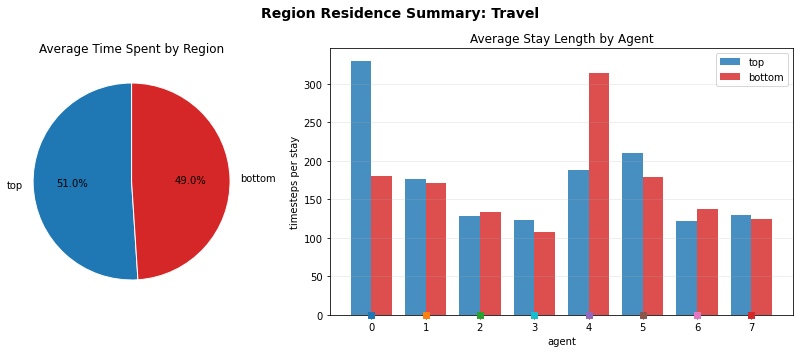

In [96]:
import importlib
import tutorials.utils.plotting as plotting
importlib.reload(plotting)

fig_single, df_single, raw_single = plotting.plot_region_residence_summary(
    runs_travel,
    mode="average",
    title="Travel",
)



'figures_pdf\\plot_region_residence_summary_runs_fixed.pdf'

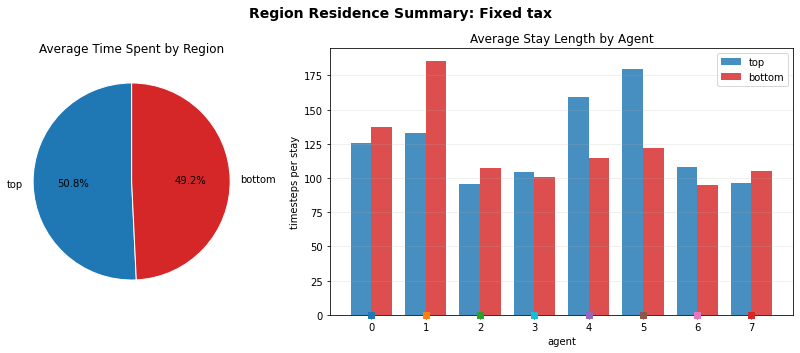

In [97]:
fig_single, df_single, raw_single = plotting.plot_region_residence_summary(
    runs_fixed,
    mode="average",
    title="Fixed tax",
)


save_fig(fig_single, "plot_region_residence_summary_runs_fixed")

'figures_pdf\\plot_travel_probability_regression.pdf'

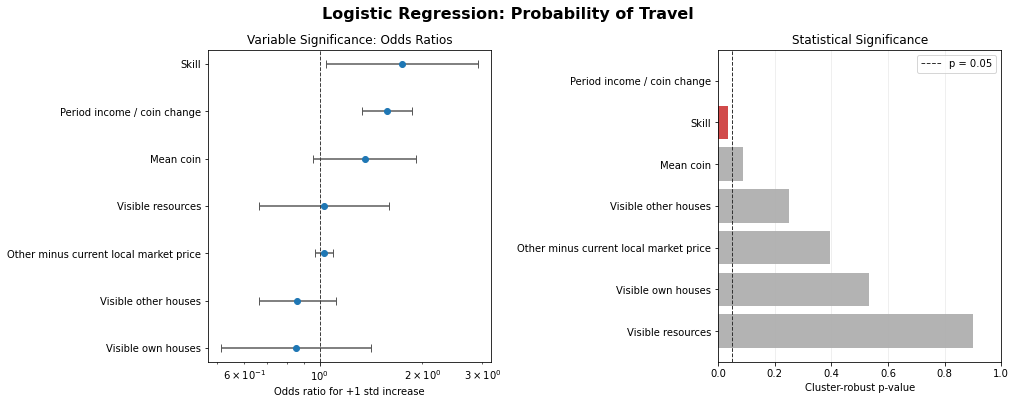

In [98]:
import importlib
import tutorials.utils.plotting as plotting
importlib.reload(plotting)

fig_reg, model_tables, reg_df, results = plotting.plot_travel_probability_regression(
    runs_travel,
    period=100,
    visible_radius=5,
    income_window=100,
    cluster_by="agent",
)

save_fig(fig_reg, "plot_travel_probability_regression")

'figures_pdf\\plot_travel_probability_by_skill_bin_5.pdf'

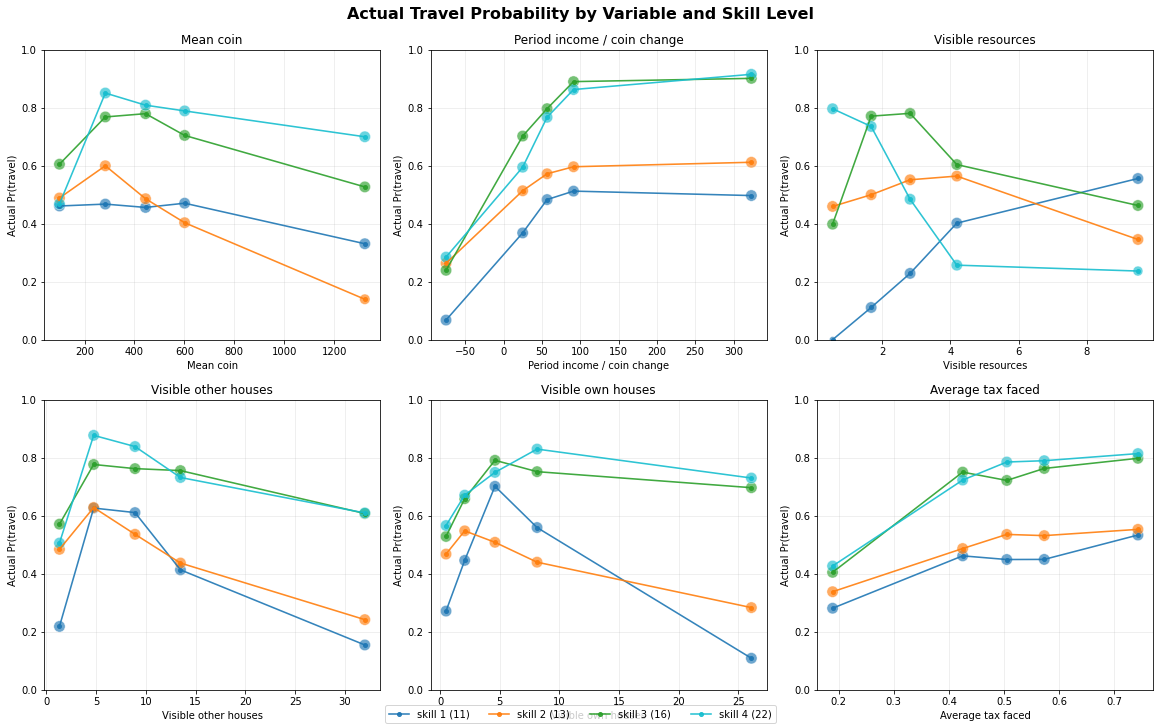

In [99]:

import importlib
import tutorials.utils.plotting as plotting
importlib.reload(plotting)

fig_skill, coef_by_skill, prob_by_skill, reg_df = plotting.plot_travel_probability_by_skill(
    runs_travel,
    period=100,
    visible_radius=5,
    income_window=100,
    rate_disc=0.05,
    n_bins=5,
)
save_fig(fig_skill, "plot_travel_probability_by_skill_bin_5")

'figures_pdf\\plot_travel_probability_regression_all_variables.pdf'

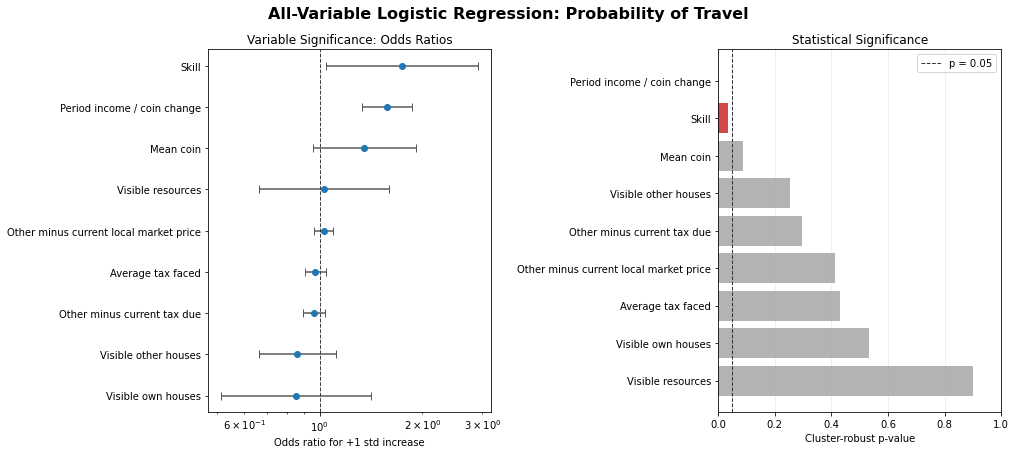

In [100]:
importlib.reload(plotting)
fig, model_tables_all, regression_df_all, results_all = plotting.plot_travel_probability_regression_all_variables(
    runs_travel,
    period=100,
    visible_radius=5,
    income_window=100,
    rate_disc=0.05,
    include_agent_fixed_effects=False,
)

save_fig(fig, "plot_travel_probability_regression_all_variables")


'figures_pdf\\plot_travel_probability_regression_all_variables_include_agent_fixed_effects.pdf'

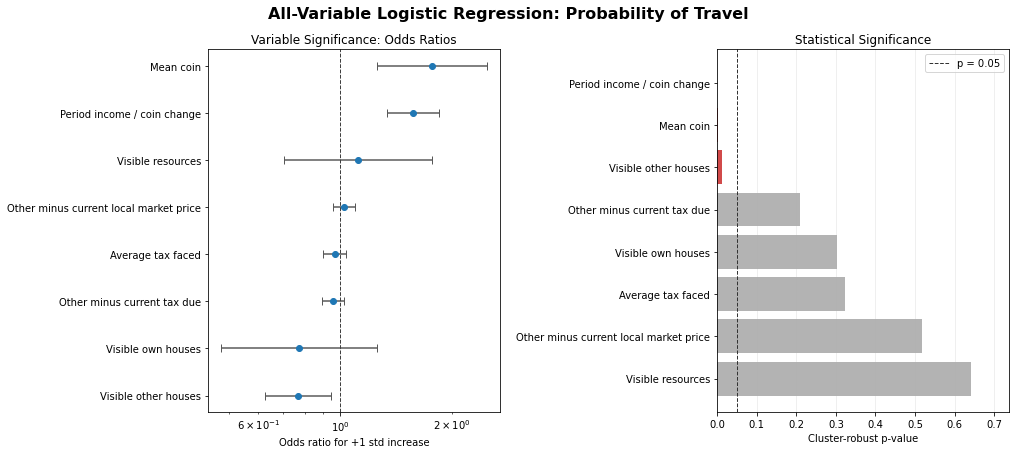

In [101]:
fig, model_tables_all, regression_df_all, results_all = plotting.plot_travel_probability_regression_all_variables(
    runs_travel,  # or a single run
    period=100,
    visible_radius=5,
    income_window=100,
    rate_disc=0.05,
    include_agent_fixed_effects=True,
)

save_fig(fig, "plot_travel_probability_regression_all_variables_include_agent_fixed_effects")

maybe swap to local minus Other region current market price 

'figures_pdf\\plot_travel_probability_regression_include_agent_fixed_effects.pdf'

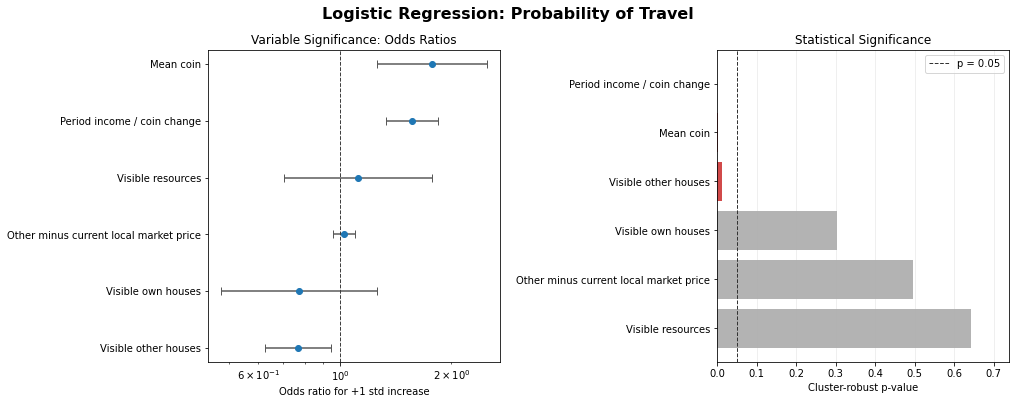

In [102]:
fig_reg_fe, tables_fe, reg_df_fe, results_fe = plotting.plot_travel_probability_regression(
    runs_travel,
    period=100,
    visible_radius=5,
    income_window=100,
    cluster_by="agent",
    include_agent_fixed_effects=True,
)

save_fig(fig_reg_fe, "plot_travel_probability_regression_include_agent_fixed_effects")

cross minus local market price
= average cross-region trade price involving the current region
 minus 
average within-region trade price in the current region.

'figures_pdf\\plot_travel_probability_regression_tax.pdf'

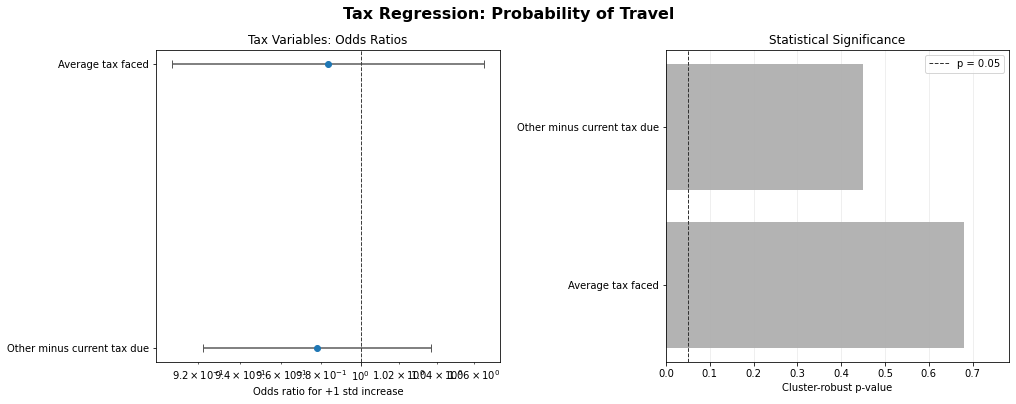

In [103]:
importlib.reload(plotting)
fig, model_tables, regression_df, results = plotting.plot_travel_probability_regression_tax(
    runs_travel,
    include_agent_fixed_effects=True,
)
save_fig(fig, "plot_travel_probability_regression_tax")

In [104]:
# importlib.reload(plotting)
# fig, model_tables, regression_df, results = plotting.plot_travel_probability_regression_tax(
#     run,
#     include_agent_fixed_effects=False,
# )


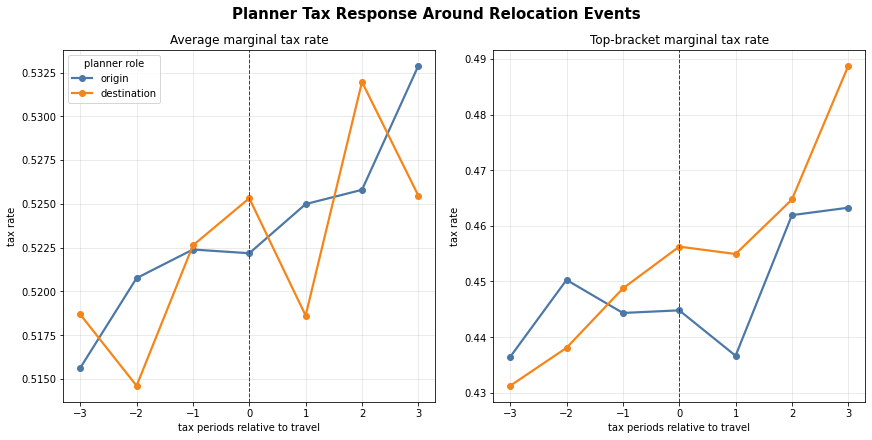

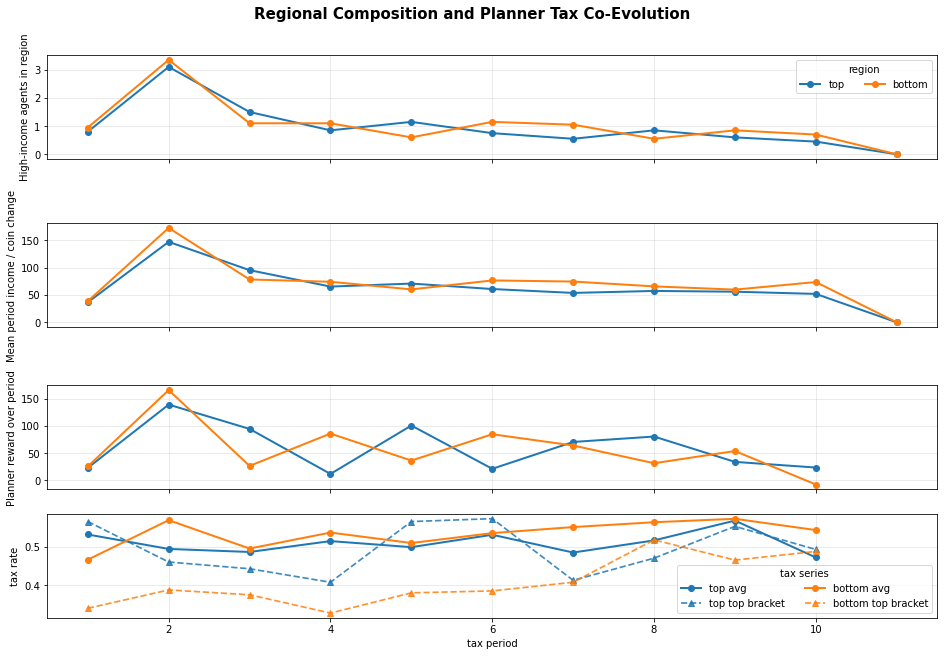

In [105]:
importlib.reload(plotting)

fig_event, event_df, event_summary = plotting.plot_relocation_tax_event_study(
    run,
    period=100,
    rate_disc=0.05,
    pre_periods=3,
    post_periods=3,
)

fig_coev, coev_df, coev_summary = plotting.plot_regional_composition_tax_coevolution(
    run,
    period=100,
    visible_radius=5,
    income_window=100,
    rate_disc=0.05,
    high_income_quantile=0.75,
)


No travel, log 0
planner_region counts:
bottom    4
top       4
final_location_region counts:
bottom    4
top       4



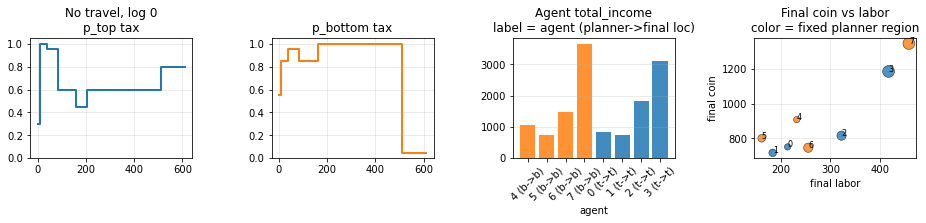

In [106]:
fig = plotting.plot_tax_and_agent_behavior_for_logs(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[
        (0, 0),
        #(0, 10),
        # (1, 2),
    ],
    top_first=True,
    short_labels=["No travel", "With travel"],
    behavior_metric="total_income",   # try: final_coin, final_labor, move_distance, region_switches
    last_bin_width=100,
)

With travel, log 0
planner_region counts:
bottom    4
top       4
majority_location_region counts:
bottom    5
top       3
final_location_region counts:
bottom    5
top       3
travel_events by agent:
agent
4    2
5    3
6    0
7    6
0    0
1    3
2    6
3    7



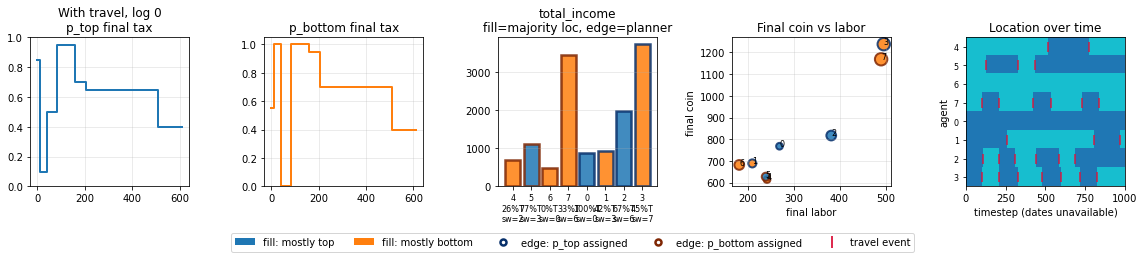

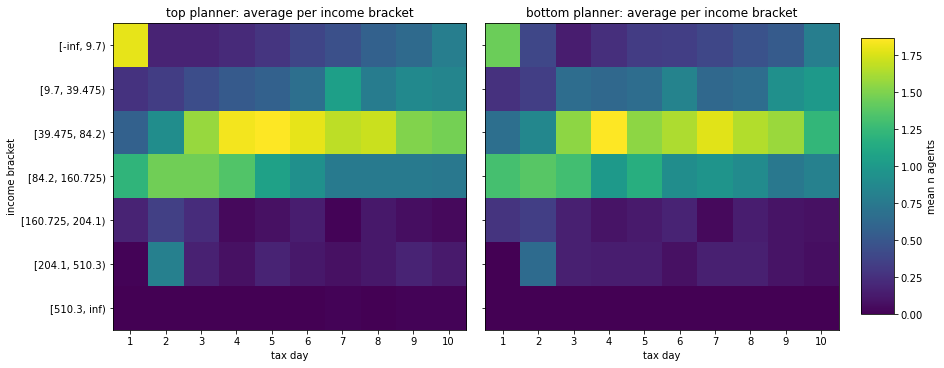

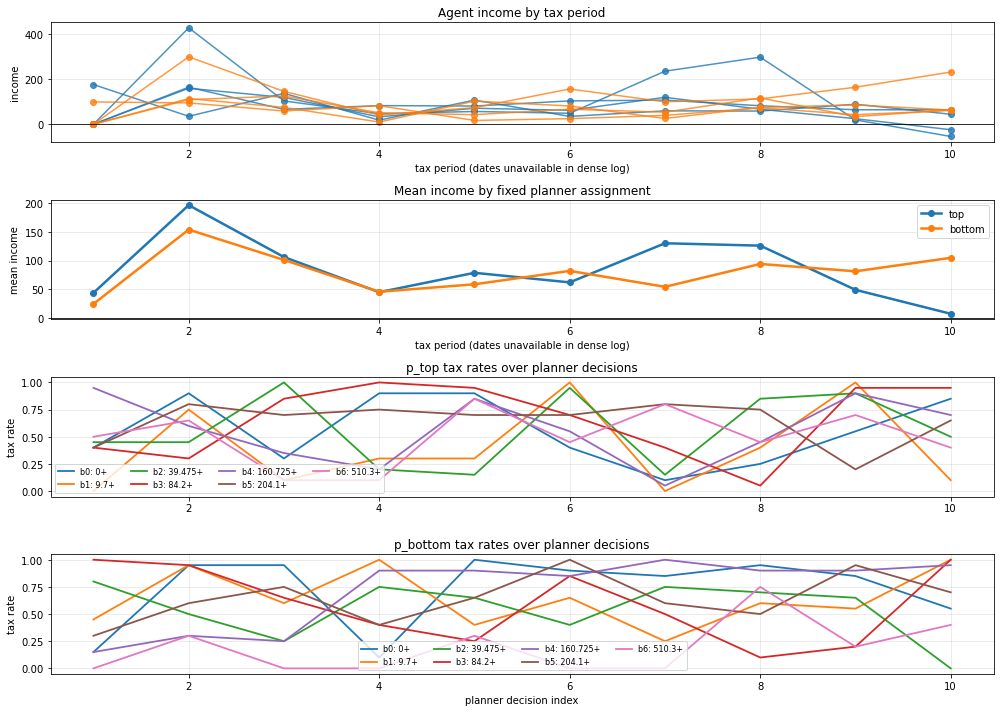

In [107]:
log = plotting._extract_logs_from_run(runs[2])[0]

fig_behavior = plotting.plot_tax_and_agent_behavior_for_logs_v2(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    selected=[(2, 0)],
    top_first=True,
    short_labels=["No travel", "With trade", "With travel"],
    behavior_metric="total_income", #"travel_events",
    last_bin_width=100,
)

fig_brackets, df_income, df_bracket_counts = plotting.plot_bracket_counts_for_log(
    runs_base,
    brackets=brackets,
    period=100,
)

save_fig(fig_brackets, "plot_bracket_counts_heatmap_runs_base")

fig_time, df_income_time = plotting.plot_income_and_tax_over_time(
    log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
)



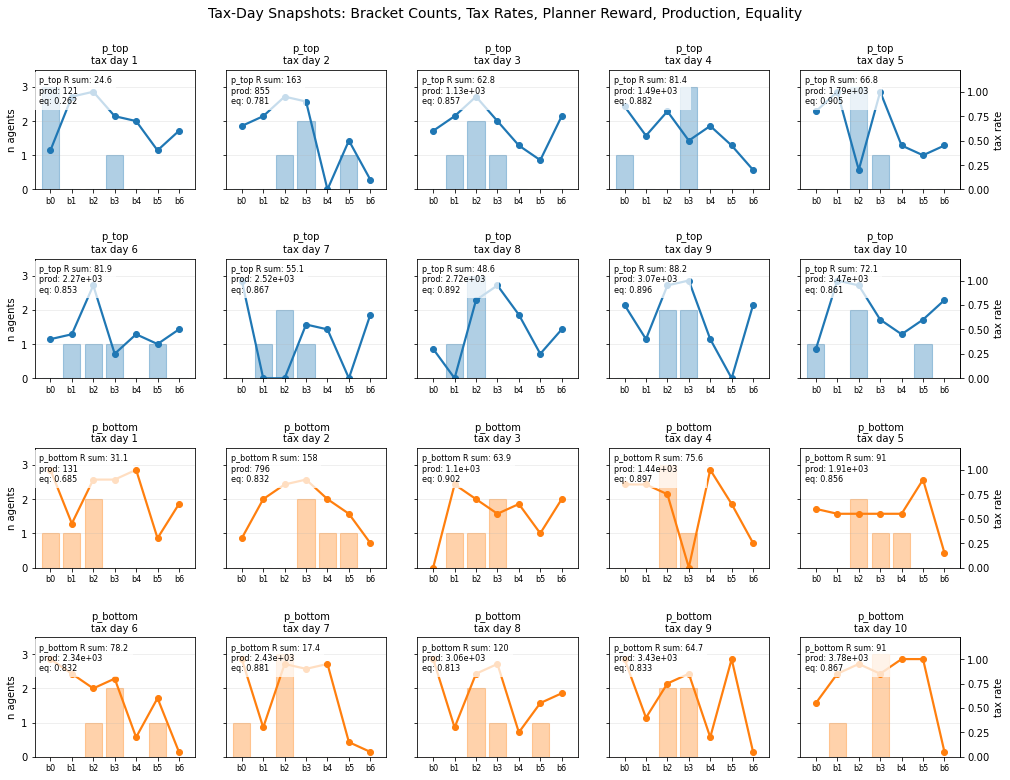

In [108]:
log = plotting._extract_logs_from_run(runs[0])[0]


fig_snap, df_income_snap, df_counts_snap, df_swf_snap = plotting.plot_tax_bracket_snapshots_compact(
    log,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    n_snapshots=10,
    top_first=True,
)


'figures_pdf\\tax_bracket_snapshots_base_runs0.pdf'

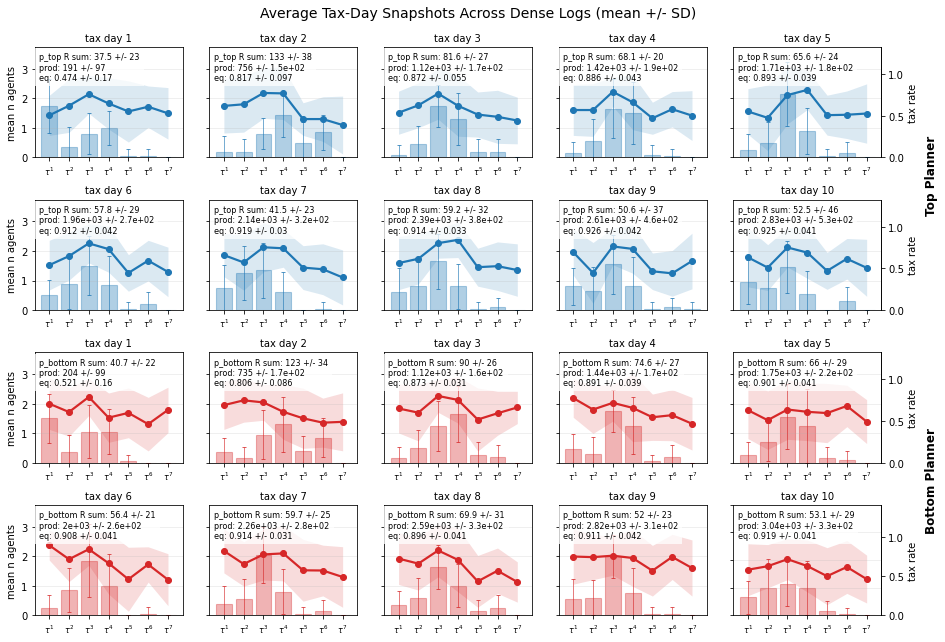

In [109]:
importlib.reload(plotting)
fig_snap, df_income_snap, df_counts_snap, df_swf_snap = plotting.plot_tax_bracket_snapshots_compact_average(
    runs_base[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    n_snapshots=10,
    top_first=True,
    show_std=True,
)

save_fig(fig_snap, "tax_bracket_snapshots_base_runs0")

'figures_pdf\\plot_tax_bracket_correlation_outcomes_average.pdf'

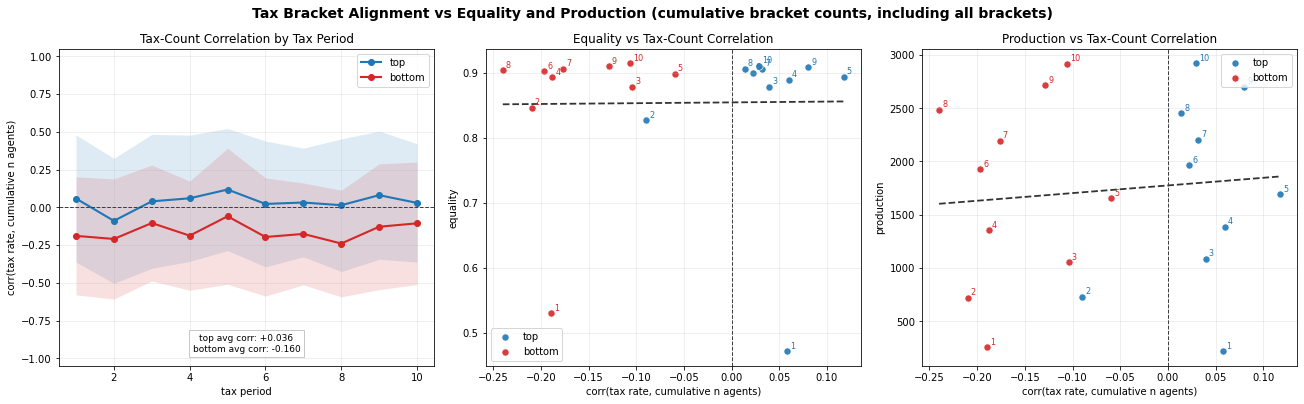

In [110]:
fig, corr_summary, corr_raw = plotting.plot_tax_bracket_correlation_outcomes_average(
    runs_base,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
    exclude_highest_bracket=False,
    min_tax_period=1,

)

save_fig(fig, "plot_tax_bracket_correlation_outcomes_average")

'figures_pdf\\plot_tax_bracket_correlation_outcomes_average_current.pdf'

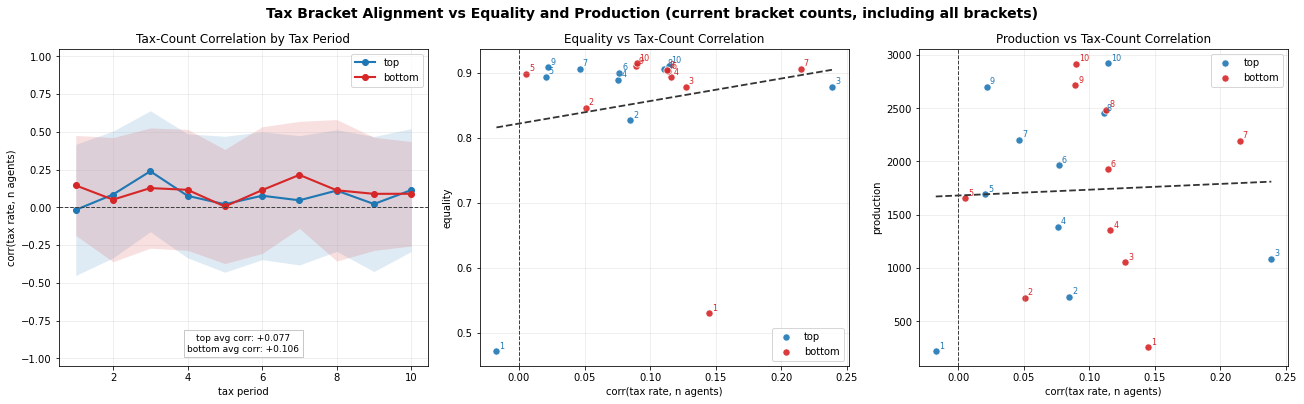

In [111]:
import importlib
import tutorials.utils.plotting as plotting
importlib.reload(plotting)
fig, corr_summary, corr_raw = plotting.plot_tax_bracket_correlation_outcomes_average(
    runs_base,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
    exclude_highest_bracket=False,
    min_tax_period=1,
    count_measure="current",
)

save_fig(fig, "plot_tax_bracket_correlation_outcomes_average_current")

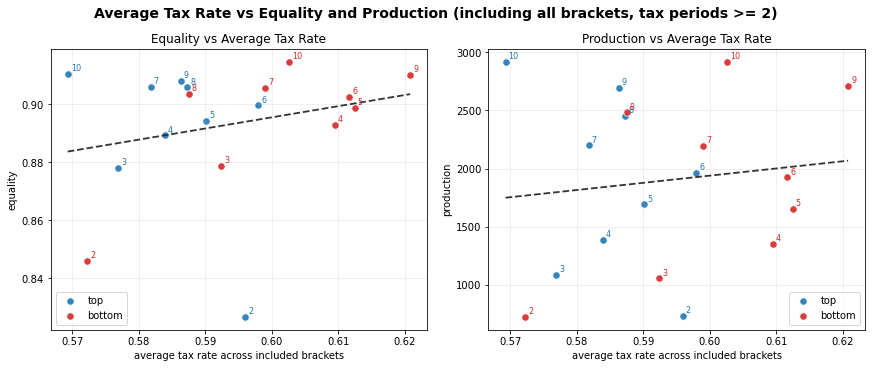

In [112]:
importlib.reload(plotting)
fig, avg_tax_summary, avg_tax_raw = plotting.plot_average_tax_rate_outcomes_average(
    runs_base,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
    exclude_highest_bracket=False,
    min_tax_period=2,
)



'figures_pdf\\compare_average_tax_schedules_by_setting.pdf'

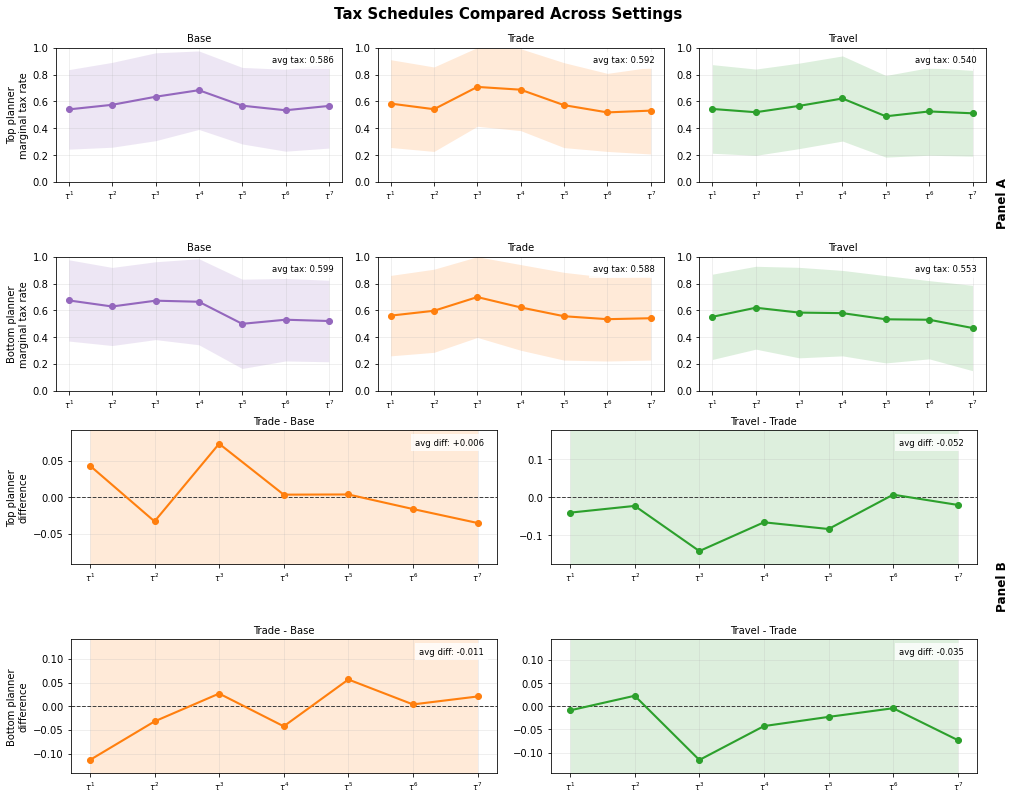

In [113]:
importlib.reload(plotting)
fig, tax_schedule_summary, tax_schedule_diff, tax_schedule_raw = (
    plotting.compare_average_tax_schedules_by_setting(
        runs_compare,
        env_obj=env_obj_phase3b,
        brackets=brackets,
        short_labels=["Base", "Trade", "Travel"],
        period=100,
        top_first=True,
        errorbar="std",
    )
)
save_fig(fig, "compare_average_tax_schedules_by_setting")

In [114]:
log = plotting._extract_logs_from_run(runs_base[0])[0]

top = log["planner_actions"]["p_top"]
bottom = log["planner_actions"]["p_bottom"]

print("p_top first half mean:", top[:, :7].mean())
print("p_top second half mean:", top[:, 7:].mean())
print("p_bottom first half mean:", bottom[:, :7].mean())
print("p_bottom second half mean:", bottom[:, 7:].mean())


p_top first half mean: 9.857142857142858
p_top second half mean: 11.428571428571429
p_bottom first half mean: 9.785714285714286
p_bottom second half mean: 12.642857142857142


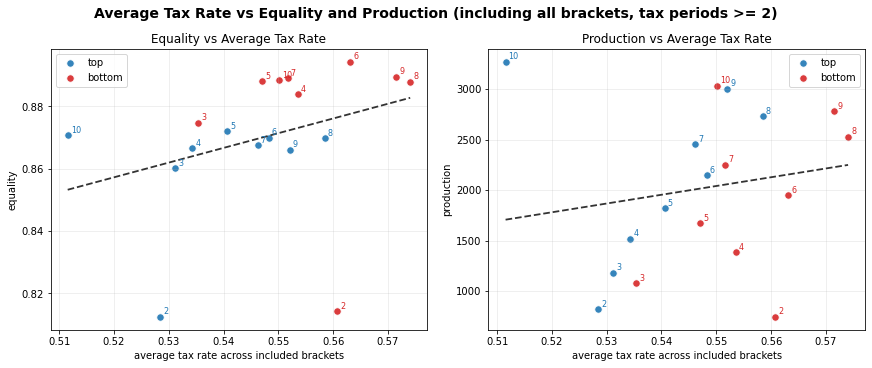

In [115]:
importlib.reload(plotting)
fig, avg_tax_summary, avg_tax_raw = plotting.plot_average_tax_rate_outcomes_average(
    runs_travel,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
    exclude_highest_bracket=False,
    min_tax_period=2,
)


'figures_pdf\\plot_agent_labor_allocation.pdf'

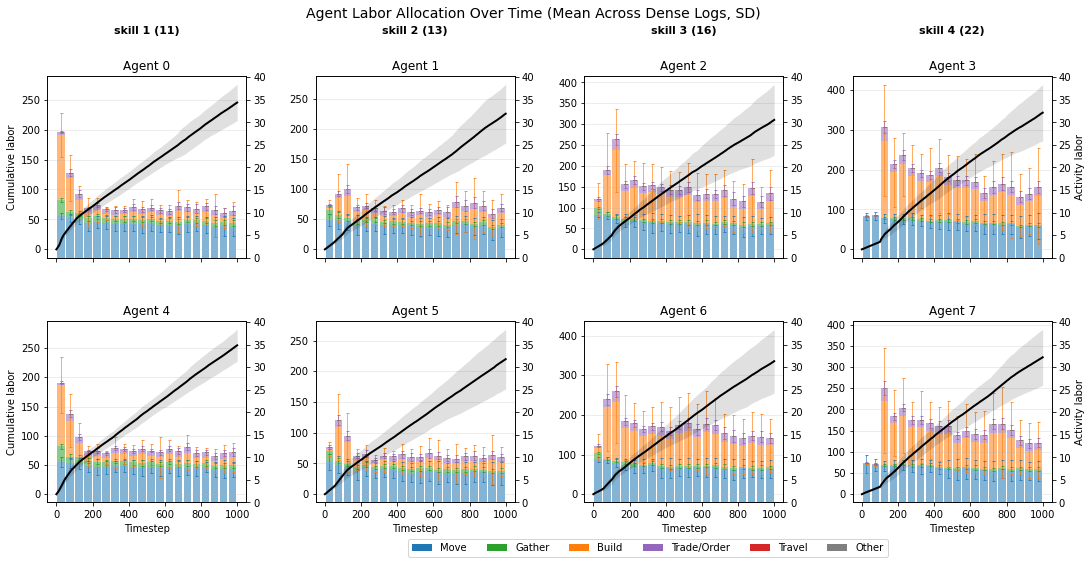

In [116]:
importlib.reload(plotting)

fig, summary_df, raw_allocation_df, raw_cumulative_df = plotting.plot_agent_labor_allocation(
    runs_base,
    mode="average",
    n_cols=4,
    bin_size=50,
)

save_fig(fig, "plot_agent_labor_allocation")

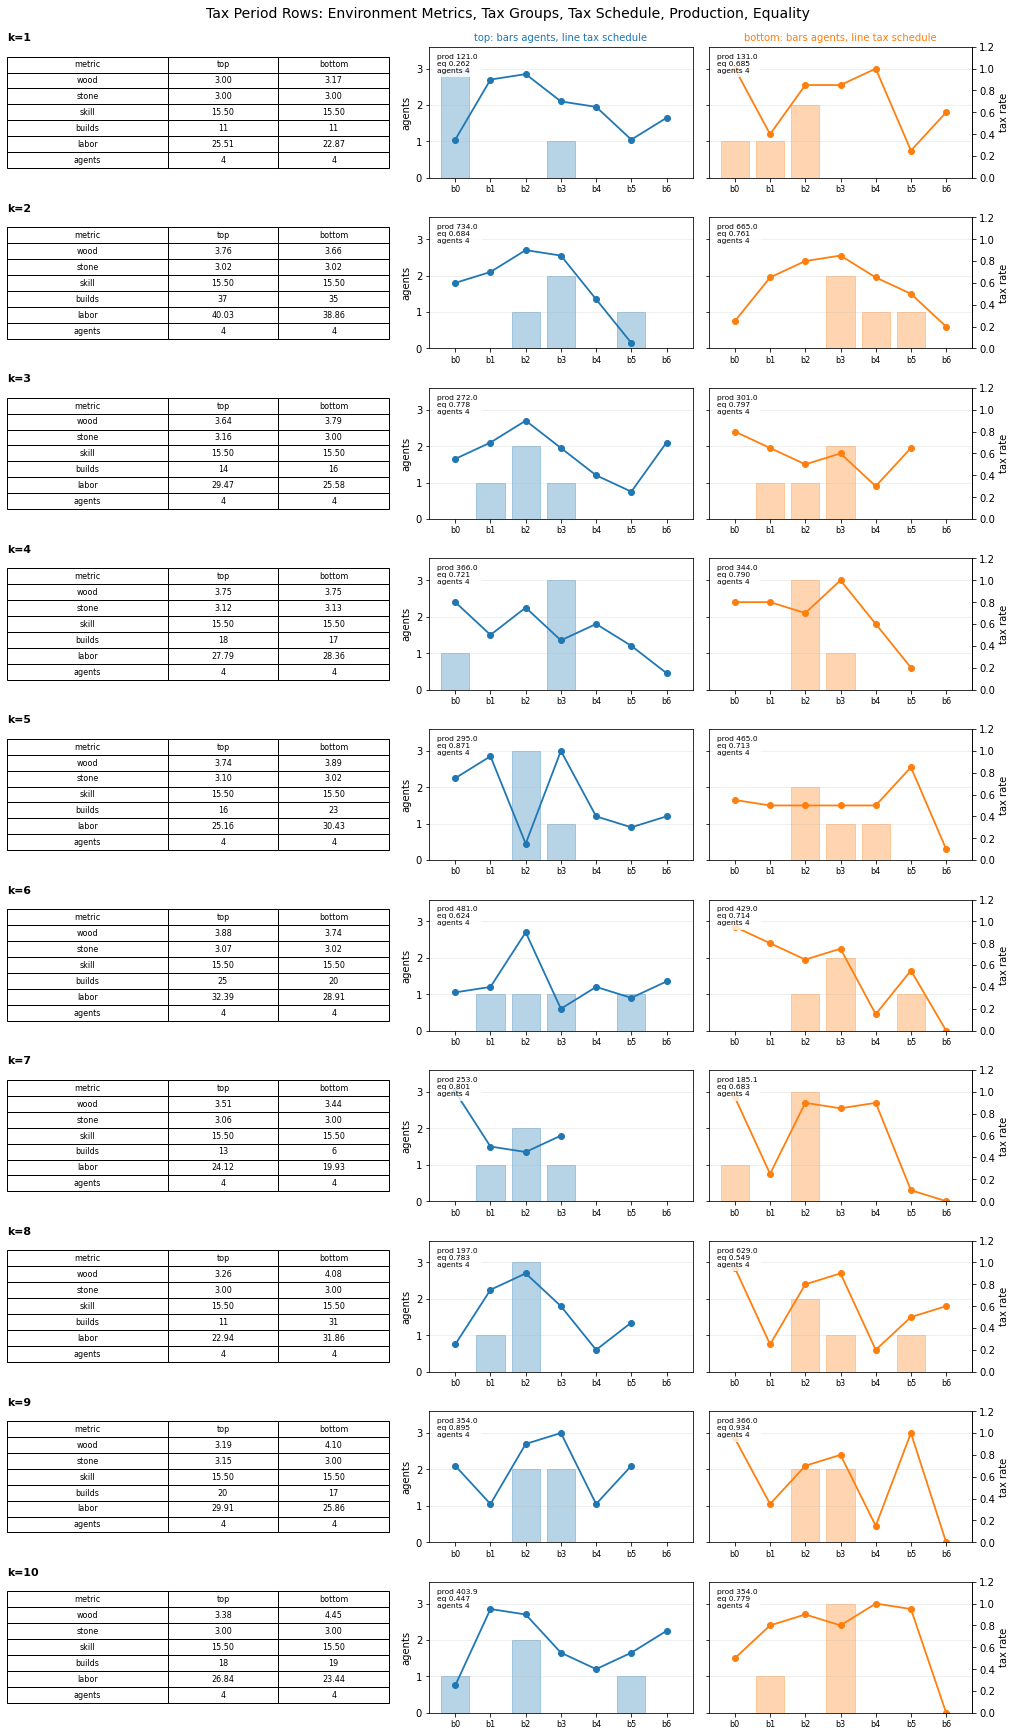

In [117]:
fig_rows, df_income, df_counts, df_outcomes, df_env, df_tax = plotting.plot_tax_period_rows_with_environment_metrics(
        log,
        brackets=brackets,
        period=100,
        n_snapshots=10,
        rate_disc=0.05,
    )


plt.show()


In [118]:
df_agent_tax, df_tax_periods = plotting.agent_tax_mobility_counterfactual_table(
    log,
    period=100,
    rate_disc=0.05,
)

df_agent_tax


,agent,skill_level,total_tax_paid_top_region,total_tax_paid_bottom_region,total_redistribution_top_region,total_redistribution_bottom_region,total_actual_tax_paid,total_counterfactual_tax_due_if_other_region,total_actual_minus_counterfactual_tax,net_tax_after_redistribution,n_tax_events_with_top_region,n_tax_events_with_bottom_region
0,0,11.0,488.48000,0.00000,549.054062,0.000000,488.48000,461.25750,27.22250,-60.574062,10,0
1,1,13.0,322.89125,0.00000,549.054062,0.000000,322.89125,315.27500,7.61625,-226.162812,10,0
2,2,16.0,445.32875,0.00000,549.054062,0.000000,445.32875,466.39750,-21.06875,-103.725312,10,0
3,3,22.0,939.51625,0.00000,549.054062,0.000000,939.51625,1062.46500,-122.94875,390.462188,10,0
4,4,11.0,0.00000,616.62375,0.000000,620.660313,616.62375,647.44750,-30.82375,-4.036563,0,10
5,5,13.0,0.00000,332.68125,0.000000,620.660313,332.68125,342.86250,-10.18125,-287.979062,0,10
6,6,16.0,0.00000,331.08625,0.000000,620.660313,331.08625,351.66125,-20.57500,-289.574062,0,10
7,7,22.0,0.00000,1202.25000,0.000000,620.660313,1202.25000,1111.03000,91.22000,581.589687,0,10


In [119]:
latex_table = df_agent_tax.to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    caption="Comparison of ML Model Performance Metrics",  # The caption to appear above the table in the LaTeX document
    label="tab:model_comparison",  # A label used for referencing the table within the LaTeX document
    position="htbp",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
    column_format="lccc",  # The format of the columns: left-aligend first column and center-aligned remaining columns as per APA guidelines
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
)

print(latex_table)

\begin{table}[htbp]
\centering
\caption{Comparison of ML Model Performance Metrics}
\label{tab:model_comparison}
\begin{tabular}{lccc}
\toprule
 agent &  skill_level &  total_tax_paid_top_region &  total_tax_paid_bottom_region &  total_redistribution_top_region &  total_redistribution_bottom_region &  total_actual_tax_paid &  total_counterfactual_tax_due_if_other_region &  total_actual_minus_counterfactual_tax &  net_tax_after_redistribution &  n_tax_events_with_top_region &  n_tax_events_with_bottom_region \\
\midrule
     0 &        11.00 &                     488.48 &                          0.00 &                           549.05 &                                0.00 &                 488.48 &                                        461.26 &                                  27.22 &                        -60.57 &                            10 &                                0 \\
     1 &        13.00 &                     322.89 &                          0.00 &                   

# debug and DF

In [120]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\results\travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028\training_metrics.csv")
cols = [c for c in df.columns if "reward" in c.lower() or "p_top" in c or "p_bottom" in c]
df[cols].tail(20)

,episode_reward_mean,episode_reward_min,episode_reward_max,policy_reward_mean/p_top,policy_reward_mean/p_bottom,policy_reward_mean/a
3980,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3981,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3982,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3983,2627.377983,1921.833034,3066.794823,667.294915,682.000369,159.760338
3984,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3985,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3986,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3987,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3988,2602.334225,1890.445560,3066.794823,667.855130,667.431201,158.380987
3989,2580.148370,1890.445560,3066.794823,657.497871,664.069651,157.322606


In [121]:
def inspect_planner_rewards(log):
    if "planner_rewards" not in log:
        print("No planner_rewards in dense log.")
        return

    for pid in ["p_top", "p_bottom"]:
        arr = np.array(log["planner_rewards"].get(pid, []), dtype=float)
        print(pid)
        print("  len:", len(arr))
        print("  finite:", np.isfinite(arr).all() if len(arr) else None)
        print("  min/max/mean/sum:", 
              np.nanmin(arr) if len(arr) else None,
              np.nanmax(arr) if len(arr) else None,
              np.nanmean(arr) if len(arr) else None,
              np.nansum(arr) if len(arr) else None)
        print("  nonzero count:", np.sum(np.abs(arr) > 1e-9) if len(arr) else 0)

In [122]:
inspect_planner_rewards(dense_logs[0])

No planner_rewards in dense log.


In [ ]:
# def planner_rewards_at_tax_days(log, period=100):
#     rows = []
#     for pid in ["p_top", "p_bottom"]:
#         arr = np.array(log.get("planner_rewards", {}).get(pid, []), dtype=float)
#         for t, val in enumerate(arr):
#             rows.append({
#                 "planner": pid,
#                 "t": t,
#                 "reward": val,
#                 "is_tax_day": (t % period == period - 1) or (t % period == 0),
#             })
#     return pd.DataFrame(rows)

# dfr = planner_rewards_at_tax_days(dense_logs[0], period=100)
# dfr.groupby(["planner", "is_tax_day"])["reward"].agg(["count", "mean", "sum", "min", "max"])

KeyError: 'planner'

In [ ]:
# from pathlib import Path
# import pickle

# run_dir = Path(run_dirs[2])  

# with open(run_dir / "dense_logs_final.pkl", "rb") as f:
#     dense_logs = pickle.load(f)

# df_income, df_tax_counts = plotting.tax_day_income_report(
#     dense_logs[0],
#     period=100,
# )

# df_income.head(16)

,tax_day_number,timestep,agent,region,state_region,location_region,split_row,coin_start,coin_end,income,tax_bracket
0,1,99,0,bottom,None,bottom,25,0.0,155.000000,155.000000,"[84.200, 160.725)"
1,1,99,1,bottom,None,bottom,25,0.0,107.000000,107.000000,"[84.200, 160.725)"
2,1,99,2,bottom,None,bottom,25,0.0,192.000000,192.000000,"[160.725, 204.100)"
3,1,99,3,bottom,None,bottom,25,0.0,14.500000,14.500000,"[9.700, 39.475)"
4,1,99,4,top,None,top,25,0.0,130.500000,130.500000,"[84.200, 160.725)"
5,1,99,5,top,None,top,25,0.0,81.900000,81.900000,"[39.475, 84.200)"
6,1,99,6,top,None,top,25,0.0,187.000000,187.000000,"[160.725, 204.100)"
7,1,99,7,bottom,None,top,25,0.0,8.700000,8.700000,"[0.000, 9.700)"
8,2,199,0,top,None,top,25,155.0,275.060500,120.060500,"[84.200, 160.725)"
9,2,199,1,top,None,top,25,107.0,129.460500,22.460500,"[9.700, 39.475)"


In [ ]:
# df_tax_counts

,tax_day_number,region,tax_bracket,n_agents
0,1,bottom,"[0.000, 9.700)",1
1,1,bottom,"[160.725, 204.100)",1
2,1,bottom,"[84.200, 160.725)",2
3,1,bottom,"[9.700, 39.475)",1
4,1,top,"[160.725, 204.100)",1
5,1,top,"[39.475, 84.200)",1
6,1,top,"[84.200, 160.725)",1
7,2,bottom,"[39.475, 84.200)",1
8,2,bottom,"[9.700, 39.475)",1
9,2,top,"[204.100, 510.300)",2


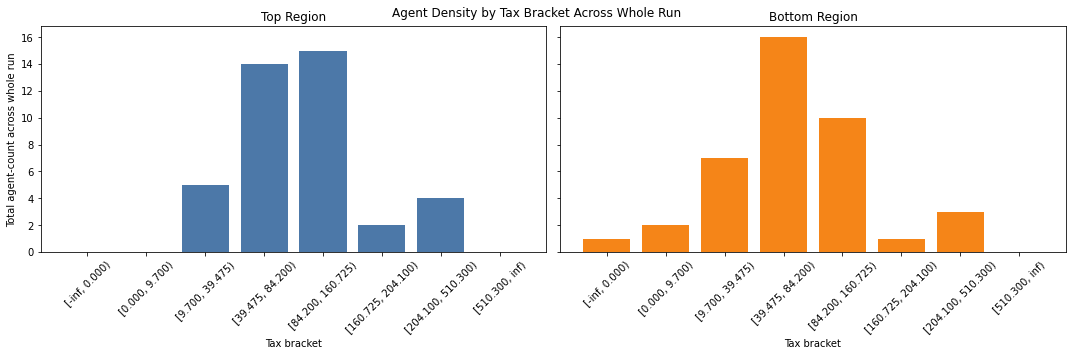

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd

# df = df_tax_counts.copy()
# df["n_agents"] = pd.to_numeric(df["n_agents"], errors="coerce").fillna(0)

# bracket_order = [
#     "[-inf, 0.000)",
#     "[0.000, 9.700)",
#     "[9.700, 39.475)",
#     "[39.475, 84.200)",
#     "[84.200, 160.725)",
#     "[160.725, 204.100)",
#     "[204.100, 510.300)",
#     "[510.300, inf)",
# ]

# # bracket_order = [
# #     "[-inf, 0.000)",
# #     "[0, 13.200)",
# #     "[13.200, 22.050)",
# #     "[22.050, 31.100)",
# #     "[31.100, 40.300)",
# #     "[40.300, 51.750)",
# #     "[51.750, 234.850)",
# #     "[234.850 , inf)",
# # ]


# counts = (
#     df.groupby(["region", "tax_bracket"])["n_agents"]
#       .sum()
#       .unstack(fill_value=0)
#       .reindex(columns=bracket_order, fill_value=0)
# )

# fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# colors = {"top": "#4C78A8", "bottom": "#F58518"}

# for ax, region in zip(axes, ["top", "bottom"]):
#     y = counts.loc[region] if region in counts.index else pd.Series(0, index=bracket_order)

#     ax.bar(y.index, y.values, color=colors[region])
#     ax.set_title(f"{region.capitalize()} Region")
#     ax.set_xlabel("Tax bracket")
#     ax.tick_params(axis="x", rotation=45)

# axes[0].set_ylabel("Total agent-count across whole run")

# plt.suptitle("Agent Density by Tax Bracket Across Whole Run")
# plt.tight_layout()
# plt.show()


In [ ]:
# all_income = []
# all_counts = []

# for rollout_id, log in dense_logs.items():
#     df_income, df_counts = plotting.tax_day_income_report(log, period=100)

#     df_income["rollout_id"] = rollout_id
#     df_counts["rollout_id"] = rollout_id

#     all_income.append(df_income)
#     all_counts.append(df_counts)

# df_income_all = pd.concat(all_income, ignore_index=True)
# df_tax_counts_all = pd.concat(all_counts, ignore_index=True)

In [ ]:
# df_income_all.head(20)
# df_tax_counts_all

,tax_day_number,region,tax_bracket,n_agents,rollout_id
0,1,bottom,"[0.000, 9.700)",1,0
1,1,bottom,"[160.725, 204.100)",1,0
2,1,bottom,"[84.200, 160.725)",2,0
3,1,bottom,"[9.700, 39.475)",1,0
4,1,top,"[160.725, 204.100)",1,0
...,...,...,...,...,...
1059,10,bottom,"[39.475, 84.200)",2,19
1060,10,bottom,"[84.200, 160.725)",1,19
1061,10,top,"[204.100, 510.300)",1,19
1062,10,top,"[39.475, 84.200)",1,19


In [ ]:
import importlib
importlib.reload(plotting)


<module 'tutorials.utils.plotting' from 'C:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\utils\\plotting.py'>

In [ ]:
#result_dir = r"results/travel-off__regionaltrade-on__layout-stacked_51x25_symetric_original__rerun original_20260430_212028"
#result_dir = r"results/travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__with_trade_20260501_163728"
#result_dir = r"results/travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__with_travel_20260502_225247"
#result_dir = r"results/travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__high_travel_cost_20260507_102202"

#result_dir = r"results/travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__trade_20260511_110634"


In [ ]:
# dense_log, dense_logs = plotting.get_dense_log_from_result_folder(result_dir, episode_key=0)

_______________:_ Agent  0 _____|_ Agent  4 _____|_ Agent  1 _____|_ Agent  5 _____|_ Agent  2 _____|_ Agent  6 _____|_ Agent  3 _____|_ Agent  7 ____
Cost (Wood)    :   4.37 (n= 43) |   3.81 (n= 63) |   3.46 (n= 56) |   3.26 (n= 78) |   4.10 (n= 50) |   3.82 (n=101) |   4.34 (n=161) |   4.20 (n=173)
Cost (Stone)   :   3.00 (n= 49) |   3.02 (n=108) |   3.00 (n= 33) |   3.04 (n= 46) |   3.00 (n= 72) |   3.01 (n=193) |   3.01 (n=201) |   3.03 (n=242)

Income (Wood)  :   4.15 (n= 80) |   4.05 (n=126) |   4.33 (n= 40) |   3.82 (n= 60) |   4.28 (n=101) |   3.96 (n=113) |   3.91 (n= 89) |   3.63 (n=116)
Income (Stone) :   3.00 (n= 84) |   3.02 (n=132) |   3.00 (n=142) |   3.06 (n=143) |   3.03 (n= 63) |   3.01 (n=165) |   3.00 (n= 66) |   3.02 (n=149)
Income (Build) :  11.00 (n= 15) |  11.00 (n= 20) |  13.00 (n= 13) |  13.00 (n= 18) |  16.00 (n= 20) |  16.00 (n= 46) |  22.00 (n= 85) |  22.00 (n= 91)


'figures_pdf\\breakdown_all_agents_single_move.pdf'

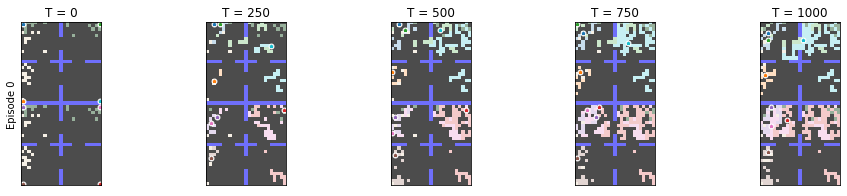

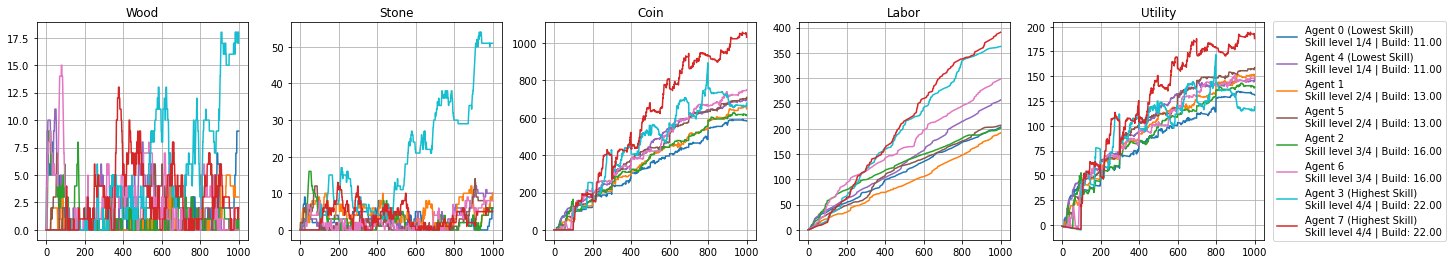

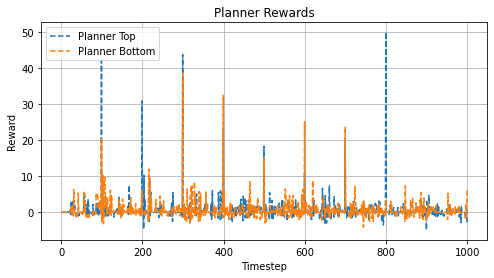

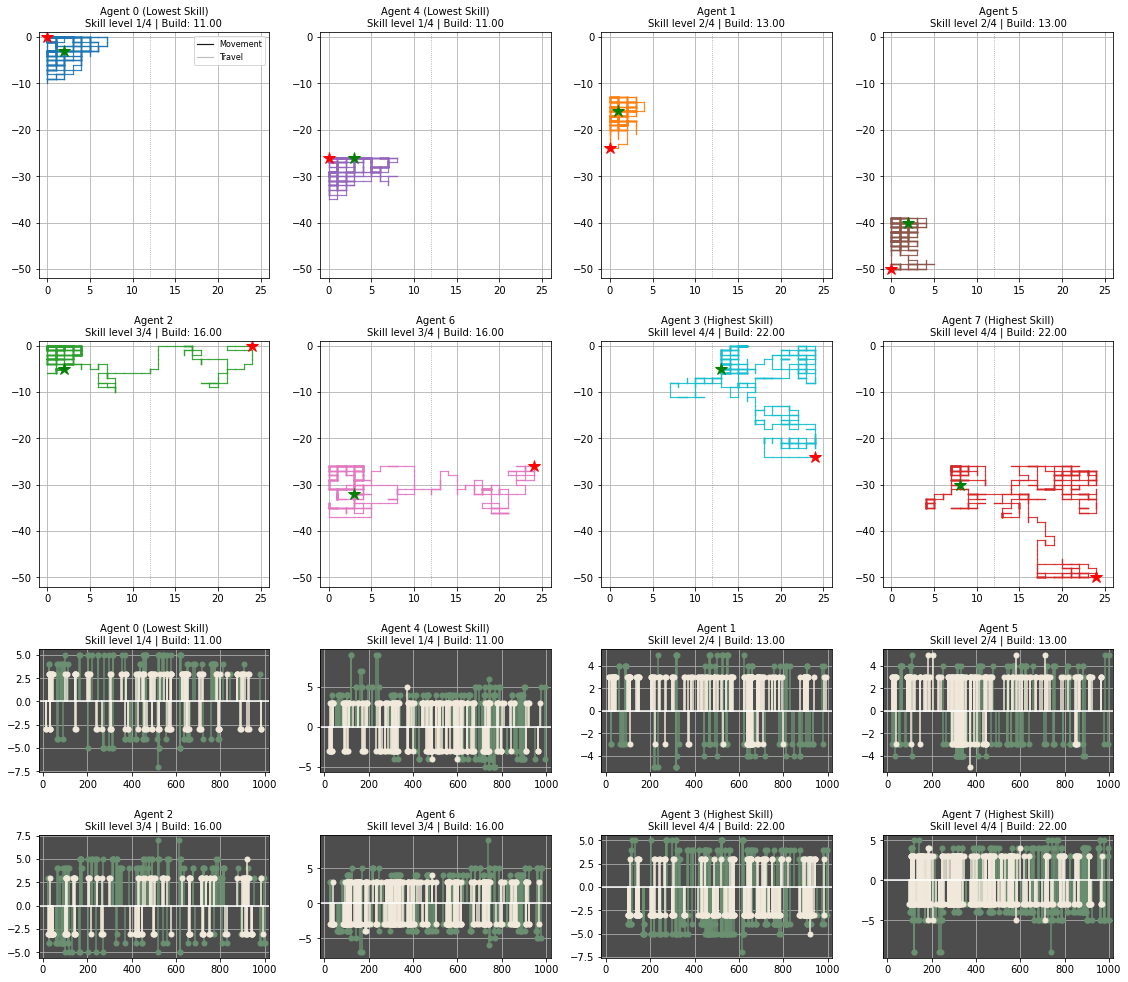

In [126]:
breakdown, dense_log, dense_logs = plotting.breakdown_all_agents_from_result_folder(
    runs_base[0],
    episode_key=5,
    #remap_key="build_payment"

)


(fig_map, fig_timeseries, fig_planner, fig_move), incomes, endows, c_trades, all_builds = breakdown

save_fig(fig_map, "breakdown_all_agents_single_map")
save_fig(fig_move, "breakdown_all_agents_single_move")

C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\utils\plotting.py:7126: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  fig_skill.subplots_adjust(bottom=0.16)


'figures_pdf\\breakdown_all_agents_average_skill.pdf'

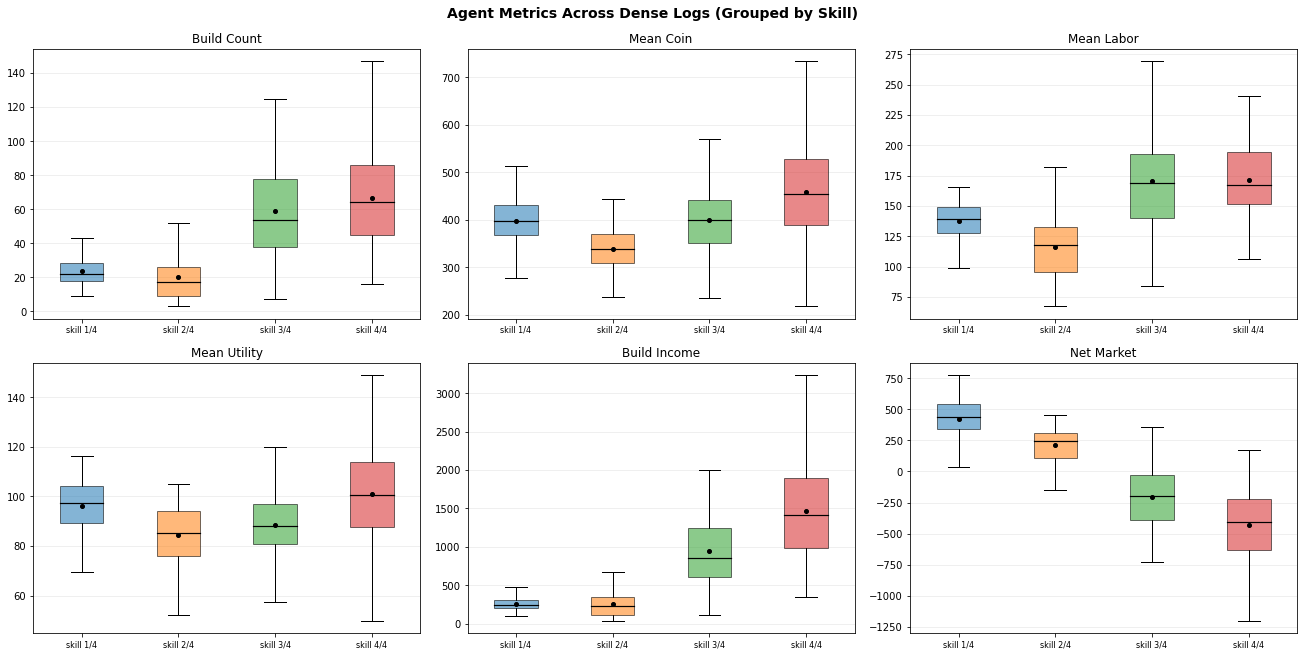

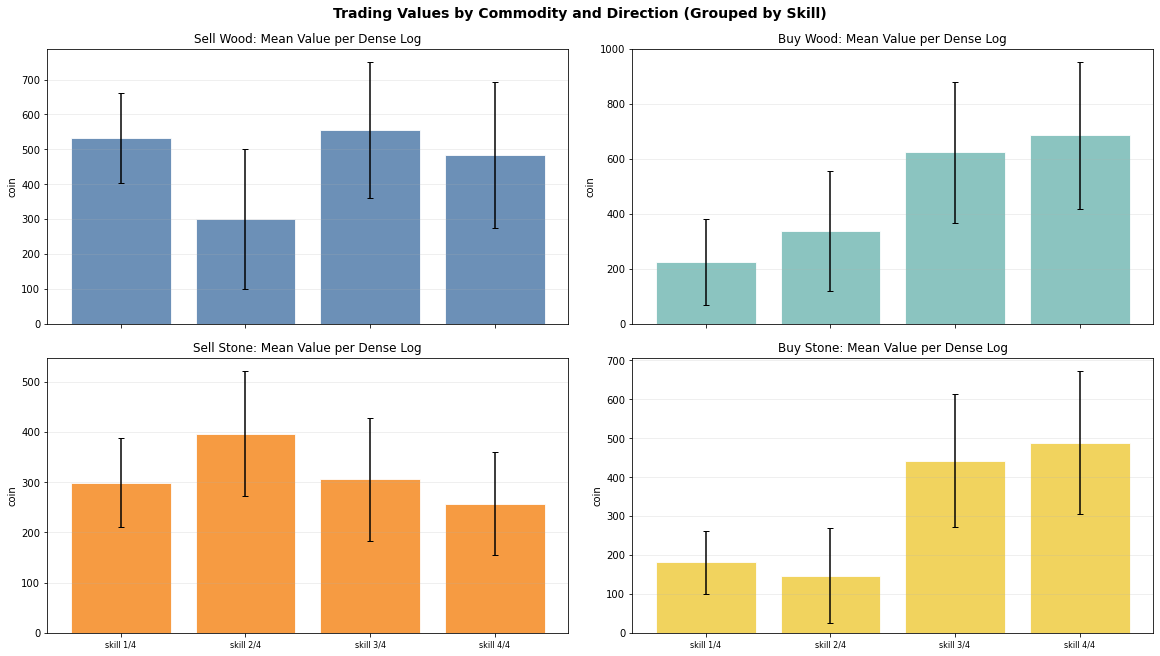

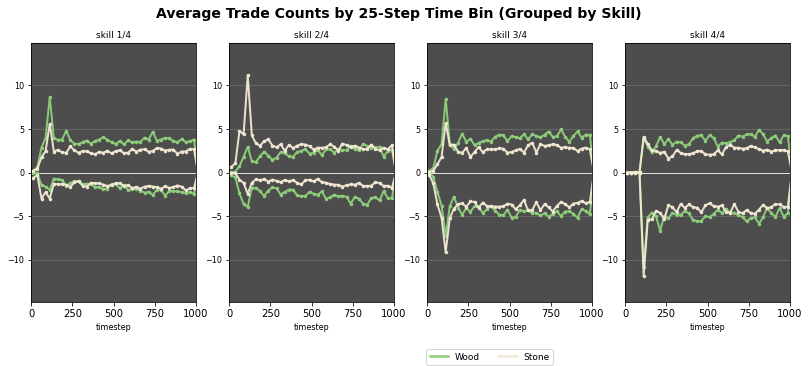

In [129]:
importlib.reload(plotting)
figures, tables, dense_logs = plotting.breakdown_all_agents_average_from_result_folder(
    runs_base,
    group_by_skill=True,
)

save_fig(figures["metrics"], "breakdown_all_agents_average_skill")

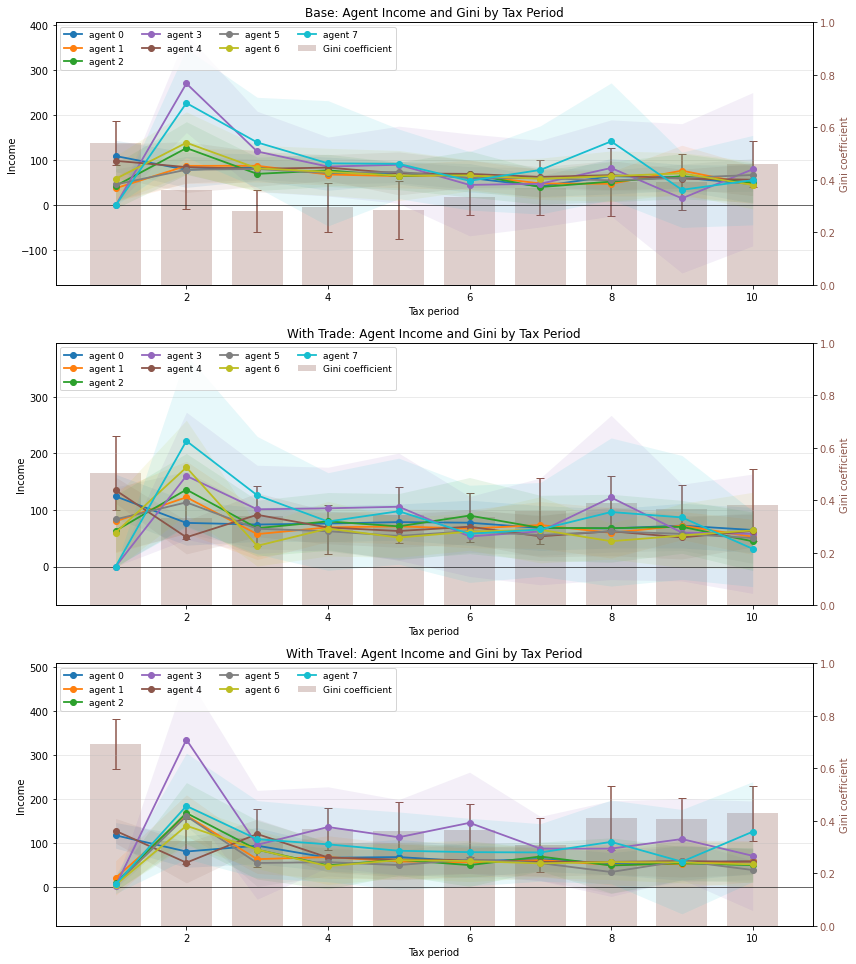

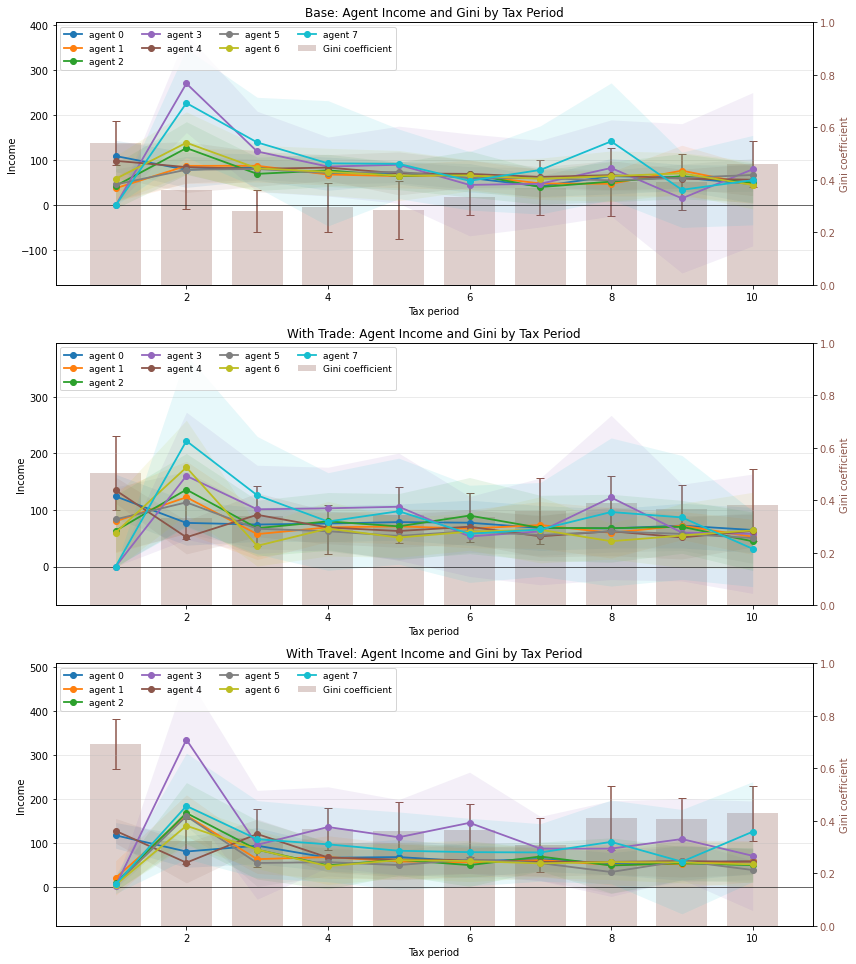

In [130]:
fig_income_gini, ax_income, ax_gini, income_summary, gini_summary, raw_income = (
    plotting.plot_agent_income_and_gini_for_runs(
        runs,
        short_labels=["Base", "With Trade", "With Travel"],
        period=100,
        max_periods=10,
        errorbar="std",
    )
)

fig_income_gini


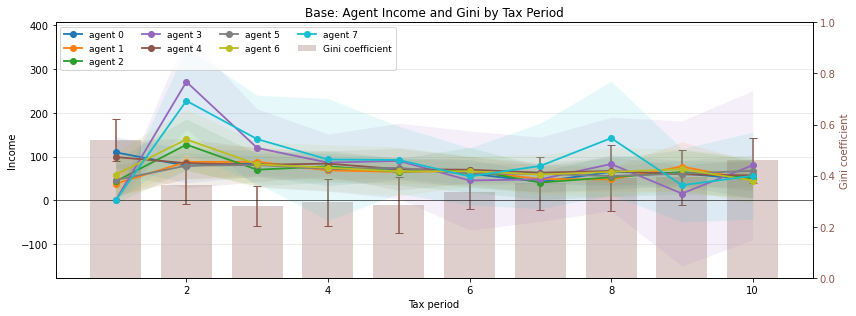

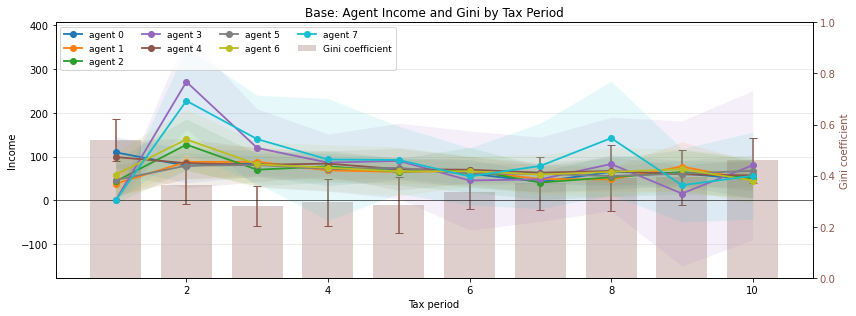

In [131]:
run = plotting.load_experiment_run(run_dirs[0])

fig, ax_income, ax_gini, income_summary, gini_summary, raw_income = (
    plotting.plot_agent_income_and_gini_for_run(
        run,
        label="Base",
        period=100,
        max_periods=10,
        errorbar="std",
    )
)

fig


# Figuring out agent movement

In [133]:
df_agents, df_summary = plotting.diagnose_agent_activity_df(runs[0]["dense_log"])
df_agents

,agent,movement,coin,wood,stone,labor
0,0,677.0,750.311562,10.0,0.0,213.24
1,1,623.0,715.900312,6.0,3.0,183.11
2,2,764.0,815.512812,3.0,1.0,322.66
3,3,741.0,1187.275312,5.0,17.0,418.04
4,4,727.0,908.036563,0.0,0.0,231.71
5,5,508.0,799.979063,0.0,0.0,160.68
6,6,649.0,745.574062,0.0,0.0,255.26
7,7,685.0,1349.410312,4.0,21.0,459.28


In [134]:
all_summaries = []

for run in runs:
    _, df_sum = plotting.diagnose_agent_activity_df(run["dense_log"])
    df_sum["run"] = run["name"]
    all_summaries.append(df_sum)

df_all = pd.concat(all_summaries, ignore_index=True)
df_all

,steps,n_builds,n_trades,n_gathers,avg_movement,total_coin,total_wood,total_stone,run
0,1000,378,1794,559,671.750,7272.0,28.0,42.0,travel-off__regionaltrade-on__layout-stacked_5...
1,1000,416,1573,576,835.125,7366.4,11.0,35.0,travel-off__regionaltrade-off__layout-stacked_...
2,1000,356,1417,528,913.000,6601.2,52.0,21.0,travel-on__regionaltrade-off__layout-stacked_5...


In [135]:
# usd_scaling = 1000
# brackets = np.array([
#     0,
#     9700,
#     39475,
#     84200,
#     160725,
#     204100,
#     510300
# ]) / usd_scaling

In [136]:
# single_dense_log = {0: dense_logs[0]}  # keep only episode 0

# fig_single = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
#     dense_logs=single_dense_log,
#     env_obj=env_obj_phase3b,
#     brackets=brackets,
#     top_first=True,
#     title="Final Marginal Tax Schedule (Single Episode)",
#     errorbar=None,  
#     last_bin_width=100,
# )

In [137]:
# fig_avg_final = plotting.plot_avg_final_tax_schedules_two_planners_from_dense_logs(
#     dense_logs=dense_logs,
#     env_obj=env_obj_phase3b,
#     brackets=brackets,
#     top_first=True,
#     title="Average Final Marginal Tax Schedules",
#     errorbar="std",
#     last_bin_width=100, 
# )

In [138]:
# fig_single = plotting.plot_planner_tax_lines(
#     dense_logs={0: dense_logs[0]},
#     env_obj=env_obj_phase3b,
#     brackets=brackets,
#     top_first=True,
#     mode="single",
#     errorbar=None,
#     title="Planner Tax Choices Over Time (Single Dense Log)"
# )

In [140]:
df_spells = plotting.agent_region_spell_table(
    runs[2]["dense_log"],
    split_row=25,
    use_region_field=False,
)
df_spells

,timesteps_top,timesteps_bottom,n_region_switches,n_top_spells,n_bottom_spells,avg_top_spell,avg_bottom_spell,avg_spell_overall,final_region
agent,,,,,,,,,
0,1001,0,0,1,0,1001.00,NaN,1001.000000,top
1,423,578,3,2,2,211.50,289.000000,250.250000,bottom
2,667,334,6,4,3,166.75,111.333333,143.000000,top
3,447,554,7,4,4,111.75,138.500000,125.125000,bottom
4,259,742,2,1,2,259.00,371.000000,333.666667,bottom
5,773,228,3,2,2,386.50,114.000000,250.250000,top
6,0,1001,0,0,1,NaN,1001.000000,1001.000000,bottom
7,330,671,6,3,4,110.00,167.750000,143.000000,bottom


# single agent single move

In [173]:
from pathlib import Path
import pickle
import ray

BASE_RESULTS_DIR = Path("tutorials/results") if Path("tutorials/results").exists() else Path("results")

result_run_dir = BASE_RESULTS_DIR / "trade_short_20260521_154655" 

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False, logging_level="ERROR")


{'node_ip_address': '192.168.1.108',
 'raylet_ip_address': '192.168.1.108',
 'redis_address': '192.168.1.108:6379',
 'object_store_address': 'tcp://127.0.0.1:62819',
 'raylet_socket_name': 'tcp://127.0.0.1:64419',
 'webui_url': 'localhost:8265',
 'session_dir': 'C:\\Users\\adria\\AppData\\Local\\Temp\\ray\\session_2026-05-30_07-53-52_531170_2756'}

In [174]:
import os
import glob
import json

def find_local_phase3b_checkpoint(run_dir):
    # Try common saved checkpoint locations inside your run folder
    candidates = glob.glob(os.path.join(run_dir, "**", "checkpoint-*"), recursive=True)

    # keep only actual checkpoint files, not metadata
    candidates = [
        p for p in candidates
        if os.path.isfile(p) and not p.endswith(".tune_metadata")
    ]

    if len(candidates) == 0:
        raise FileNotFoundError(f"No checkpoint-* file found inside {run_dir}")

    # choose latest checkpoint number
    def ckpt_num(path):
        base = os.path.basename(path)
        return int(base.split("-")[-1])

    return sorted(candidates, key=ckpt_num)[-1]

In [175]:
import sys
import importlib

PROJECT_ROOT = r"C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-"
TUTORIALS_DIR = PROJECT_ROOT + r"\tutorials"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

if TUTORIALS_DIR not in sys.path:
    sys.path.append(TUTORIALS_DIR)

from rllib import tf_models
importlib.reload(tf_models)


<module 'rllib.tf_models' from 'c:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\rllib\\tf_models.py'>

In [176]:
from pathlib import Path

def load_trainer_from_run(run_dir, settings):
    import json

    run_dir = Path(run_dir)  # <-- important fix

    with open(run_dir / "config.json", "r") as f:
        cfg = json.load(f)

    with open(run_dir / "checkpoints.json", "r") as f:
        ckpts = json.load(f)

    env_config = cfg["env_config_dict_phase3b"]

    env_obj = exp.create_env(env_config)

    trainer = exp.create_trainer(
        settings=settings,
        env_config_dict=env_config,
        env_obj=env_obj,
        policies_to_train=["a", "p_top", "p_bottom"],
    )
 
    local_ckpt = find_local_phase3b_checkpoint(run_dir)
    print("Restoring from:", local_ckpt)
    trainer.restore(local_ckpt)

    return trainer, env_obj

In [177]:
import simulation as exp
result_run_dir = BASE_RESULTS_DIR / "trade_short_20260521_154655"

with open(result_run_dir / "config.json", "r") as f:
    cfg = json.load(f)

env_config = cfg["env_config_dict_phase3b"]
env_obj_phase3b = exp.create_env(env_config)


In [178]:
obs = env_obj_phase3b.reset()
print(obs["p_bottom"]["flat"].shape)
print(obs["p_top"]["flat"].shape)
print(obs["0"]["flat"].shape)


(63,)
(63,)
(153,)


In [179]:
from utils import single

In [180]:
import os
os.environ["RAY_DISABLE_MEMORY_MONITOR"] = "1" 

from pathlib import Path, PurePosixPath
import json
import pickle
from dataclasses import fields

import ray
import simulation as exp
from utils import single

ray.shutdown()
ray.init(
    ignore_reinit_error=True,
    log_to_driver=False,
    logging_level="ERROR",
)

BASE_RESULTS_DIR = Path("tutorials/results") if Path("tutorials/results").exists() else Path("results")

result_run_dir = BASE_RESULTS_DIR / "trade_short_20260521_154655"

with open(result_run_dir / "config.json", "r") as f:
    cfg = json.load(f)

with open(result_run_dir / "checkpoints.json", "r") as f:
    ckpts = json.load(f)

with open(result_run_dir / "dense_logs_final.pkl", "rb") as f:
    dense_logs = pickle.load(f)

settings_from_result = exp.ExperimentSettings(**{
    f.name: cfg[f.name]
    for f in fields(exp.ExperimentSettings)
    if f.name in cfg
})

env_config = cfg["env_config_dict_phase3b"]
env_obj_phase3b = exp.create_env(env_config)


def checkpoint_ok(path):
    path = Path(path)
    return path.exists() and Path(str(path) + ".tune_metadata").exists()


def find_phase3b_checkpoint(run_dir, checkpoint_from_json):
    candidates = []

    # 1. If checkpoint files were copied into the result folder, prefer those.
    local_candidates = [
        p for p in run_dir.rglob("checkpoint-*")
        if p.is_file() and not str(p).endswith(".tune_metadata")
    ]

    def ckpt_num(path):
        try:
            return int(path.name.split("-")[-1])
        except ValueError:
            return -1

    candidates.extend(sorted(local_candidates, key=ckpt_num, reverse=True))

    # 2. Try the path exactly as stored in checkpoints.json.
    candidates.append(Path(checkpoint_from_json))

    # 3. Convert the Linux /home/.../ray_results path to this Windows user's ~/ray_results.
    posix_path = PurePosixPath(checkpoint_from_json)
    if len(posix_path.parts) >= 3:
        candidates.append(
            Path.home()
            / "ray_results"
            / posix_path.parts[-3]
            / posix_path.parts[-2]
            / posix_path.parts[-1]
        )

    tried = []
    for candidate in candidates:
        candidate = Path(candidate)
        tried.append(str(candidate))
        if checkpoint_ok(candidate):
            return candidate

    raise FileNotFoundError(
        "Could not find a valid Phase 3B checkpoint. Tried:\n"
        + "\n".join(tried)
        + "\n\nYou need the checkpoint file and its .tune_metadata file locally."
    )


checkpoint_path = find_phase3b_checkpoint(result_run_dir, ckpts["phase3b"])
print("Restoring checkpoint:", checkpoint_path)
print("Checkpoint exists:", Path(checkpoint_path).exists())
print("Metadata exists:", Path(str(checkpoint_path) + ".tune_metadata").exists())

from ray.rllib.models import ModelCatalog
from rllib.tf_models import KerasLinear, KerasConvLSTM, RandomAction

ModelCatalog.register_custom_model("keras_linear", KerasLinear)
ModelCatalog.register_custom_model("keras_conv_lstm", KerasConvLSTM)
ModelCatalog.register_custom_model("random", RandomAction)


trainer_phase3b = exp.create_trainer(
    settings=settings_from_result,
    env_config_dict=env_config,
    env_obj=env_obj_phase3b,
    policies_to_train=["a", "p_top", "p_bottom"],
)

obs = env_obj_phase3b.reset()

print("Result folder:", result_run_dir)
print("Checkpoint:", checkpoint_path)

p_bottom_agent_keys = sorted(
    k for k in obs["p_bottom"]
    if k.startswith("p") and k[1:].isdigit()
)

print("p_bottom planner agent keys:", p_bottom_agent_keys)
print("p_bottom flat shape:", obs["p_bottom"]["flat"].shape)


trainer_phase3b.restore(str(checkpoint_path))
print("Restored trainer_phase3b")


2026-05-30 07:54:04,830	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-05-30 07:54:04,955	WARNING deprecation.py:30 -- DeprecationWarning: `ray.rllib.models.tf.recurrent_tf_model_v2.RecurrentTFModelV2` has been deprecated. Use `ray.rllib.models.tf.recurrent_net.RecurrentNetwork` instead. This will raise an error in the future!


Restoring checkpoint: results\trade_short_20260521_154655\ray_checkpoints\phase3b\checkpoint_1500\checkpoint-1500
Checkpoint exists: True
Metadata exists: True


2026-05-30 07:55:51,928	WARNING deprecation.py:30 -- DeprecationWarning: `ray.rllib.models.tf.recurrent_tf_model_v2.RecurrentTFModelV2` has been deprecated. Use `ray.rllib.models.tf.recurrent_net.RecurrentNetwork` instead. This will raise an error in the future!
2026-05-30 07:56:02,887	WARNING deprecation.py:30 -- DeprecationWarning: `ray.rllib.models.tf.recurrent_tf_model_v2.RecurrentTFModelV2` has been deprecated. Use `ray.rllib.models.tf.recurrent_net.RecurrentNetwork` instead. This will raise an error in the future!
2026-05-30 07:58:53,964	ERROR worker.py:987 -- Possible unhandled error from worker: ray::RolloutWorker.set_weights() (pid=5848, ip=192.168.1.108)
  File "c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\ray\thirdparty_files\psutil\_pswindows.py", line 780, in cmdline
    ret = cext.proc_cmdline(self.pid, use_peb=True)
PermissionError: [WinError 5] Access is denied: '(originated from OpenProcess)'

During handling of the above exception, another exception o

Result folder: results\trade_short_20260521_154655
Checkpoint: results\trade_short_20260521_154655\ray_checkpoints\phase3b\checkpoint_1500\checkpoint-1500
p_bottom planner agent keys: ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7']
p_bottom flat shape: (63,)
Restored trainer_phase3b


In [181]:
import importlib
from utils import single

importlib.reload(single)


<module 'utils.single' from 'c:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\utils\\single.py'>

In [182]:
paired_baseline_log, paired_forced_log = single.generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)


2026-05-30 07:59:27,538	ERROR worker.py:987 -- Possible unhandled error from worker: ray::RolloutWorker.restore() (pid=19836, ip=192.168.1.108)
  File "c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\ray\thirdparty_files\psutil\_pswindows.py", line 780, in cmdline
    ret = cext.proc_cmdline(self.pid, use_peb=True)
PermissionError: [WinError 5] Access is denied: '(originated from OpenProcess)'

During handling of the above exception, another exception occurred:

ray::RolloutWorker.restore() (pid=19836, ip=192.168.1.108)
  File "c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\ray\thirdparty_files\psutil\_pswindows.py", line 679, in wrapper
    return fun(self, *args, **kwargs)
  File "c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\ray\thirdparty_files\psutil\_pswindows.py", line 695, in wrapper
    return fun(self, *args, **kwargs)
  File "c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\ray\thirdparty_files\psutil\_pswindows.py", 

In [183]:
forced_log = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=3,
    forced_timestep=400,
    forced_target_region="bottom",
    explore=False,
)

In [184]:
df_move_summary = single.forced_move_agent_summary(forced_log, window_before=100, window_after=100)
df_move_summary

,period,agent,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,trade_cashflow
0,before_move,3,300,399,99.000,31.54,67.932609,5,110.0,6,1,3,6,-11.0
1,after_move,3,401,500,47.889,38.98,74.160567,7,154.0,8,0,63,60,-49.0


In [185]:
df_move_events = single.forced_move_event_table(forced_log, window=80)
df_move_events.head(20)
df_move_events.tail(20)

,t,relative_t,region,coin,wood,stone,labor,utility,built,bought_wood,sold_wood,bought_stone,sold_stone
141,461,61,bottom,313.417813,0.0,2.0,126.60,79.505826,0,0,0,1,0
142,462,62,bottom,309.417813,0.0,3.0,126.91,80.519277,0,0,0,0,1
143,463,63,bottom,313.417813,0.0,2.0,127.17,80.475177,0,0,0,0,0
144,464,64,bottom,313.417813,0.0,2.0,127.38,79.352526,0,0,0,1,0
145,465,65,bottom,309.417813,0.0,3.0,127.64,78.216195,0,0,0,1,0
146,466,66,bottom,305.417813,0.0,4.0,127.95,78.161595,0,0,0,0,0
147,467,67,bottom,305.417813,0.0,4.0,128.21,79.178226,0,0,0,1,2
148,468,68,bottom,309.417813,0.0,3.0,128.47,79.123626,0,0,0,0,0
149,469,69,bottom,309.417813,0.0,3.0,128.73,79.079526,0,0,0,0,0
150,470,70,bottom,309.417813,0.0,3.0,128.94,80.092977,0,0,0,1,2


In [186]:
forced_log_200 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=3,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

forced_log_400 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=3,
    forced_timestep=400,
    forced_target_region="bottom",
    explore=False,
)

forced_log_600 = single.generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=3,
    forced_timestep=600,
    forced_target_region="bottom",
    explore=False,
)

In [210]:
import importlib
import tutorials.utils.single as single
importlib.reload(single)


<module 'tutorials.utils.single' from 'C:\\Users\\adria\\coding\\katja\\DRL-in-international-economy-ai-economist-\\tutorials\\utils\\single.py'>

In [ ]:
baseline_logs, forced_logs = single.generate_paired_baseline_forced_rollout_batch(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    n_rollouts=20,
    forced_agent_id=0,
    forced_timestep=250,
    forced_target_region="bottom",
    forced_move_seed=0,
    explore=False,
    progress=True,
)



Generating paired rollout 1/20
Generating paired rollout 2/20
Generating paired rollout 3/20
Generating paired rollout 4/20
Generating paired rollout 5/20
Generating paired rollout 6/20
Generating paired rollout 7/20
Generating paired rollout 8/20
Generating paired rollout 9/20
Generating paired rollout 10/20
Generating paired rollout 11/20
Generating paired rollout 12/20
Generating paired rollout 13/20
Generating paired rollout 14/20
Generating paired rollout 15/20
Generating paired rollout 16/20
Generating paired rollout 17/20
Generating paired rollout 18/20
Generating paired rollout 19/20
Generating paired rollout 20/20


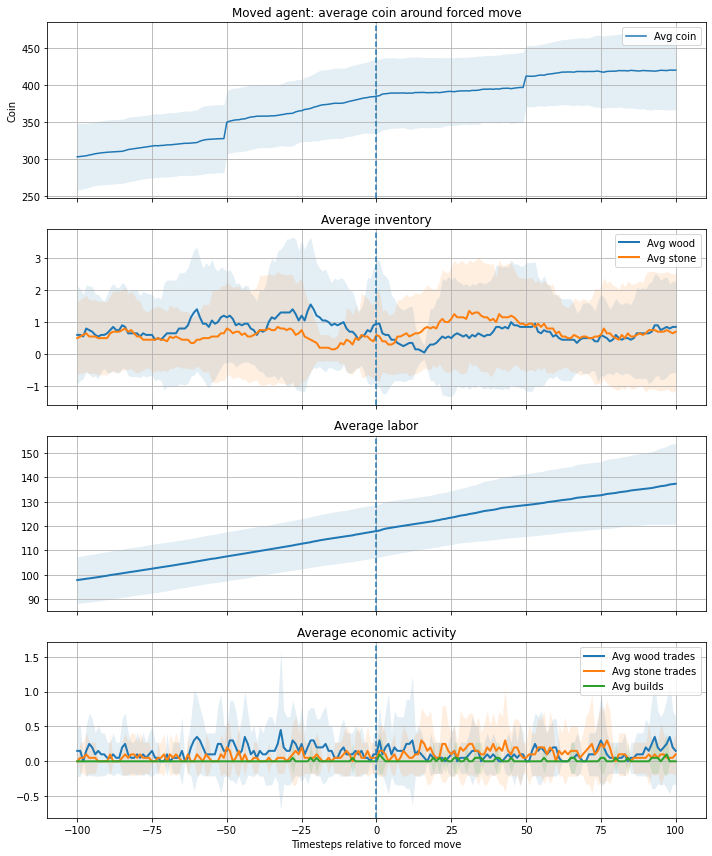

In [212]:
importlib.reload(single)

fig, summary_df, raw_df = single.plot_forced_move_timeseries(forced_logs, window=100)


'figures_pdf\\plot_forced_move_utilities_system_450_0.pdf'

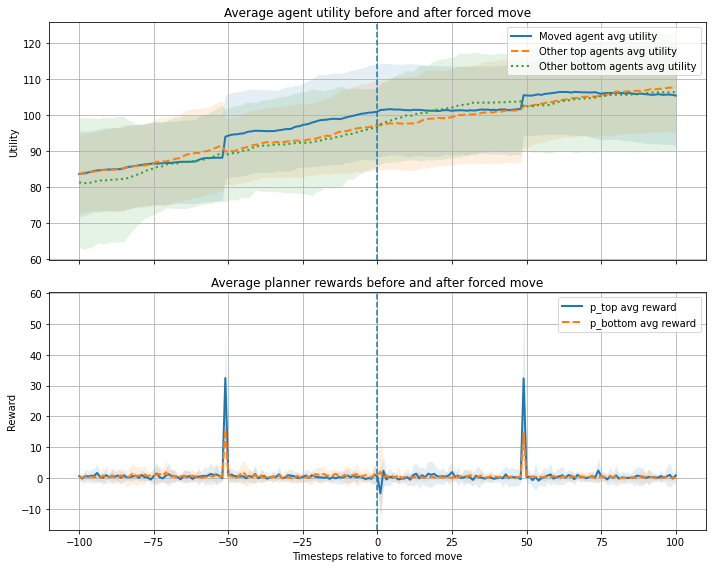

In [ ]:
importlib.reload(single)

fig, summary_df, raw_df = single.plot_forced_move_utilities_system(forced_logs, window=100)

save_fig(fig, "plot_forced_move_utilities_system_0")


In [215]:
# Pick highest-skill agent currently in the top region
env_obj_phase3b.reset()

world = env_obj_phase3b.env.world
split = world.world_size[0] // 2

top_agents = []
for agent in world.agents:
    aid = int(agent.idx)
    row = int(agent.loc[0])

    if row < split:
        build_payment = float(agent.state.get("build_payment", float("nan")))
        top_agents.append((build_payment, aid, tuple(agent.loc)))

top_agents = sorted(top_agents, reverse=True)
forced_agent_id = top_agents[0][1]

print("Selected top-region highest-skill agent:", forced_agent_id)
print("build_payment, agent_id, loc:", top_agents[0])
print("All top agents:", top_agents)

Selected top-region highest-skill agent: 3
build_payment, agent_id, loc: (22.0, 3, (24, 24))
All top agents: [(22.0, 3, (24, 24)), (16.0, 2, (0, 24)), (13.0, 1, (24, 0)), (11.0, 0, (0, 0))]


Generating paired rollout 1/20
Generating paired rollout 2/20
Generating paired rollout 3/20
Generating paired rollout 4/20
Generating paired rollout 5/20
Generating paired rollout 6/20
Generating paired rollout 7/20
Generating paired rollout 8/20
Generating paired rollout 9/20
Generating paired rollout 10/20
Generating paired rollout 11/20
Generating paired rollout 12/20
Generating paired rollout 13/20
Generating paired rollout 14/20
Generating paired rollout 15/20
Generating paired rollout 16/20
Generating paired rollout 17/20
Generating paired rollout 18/20
Generating paired rollout 19/20
Generating paired rollout 20/20


'figures_pdf\\plot_forced_move_utilities_system_3.pdf'

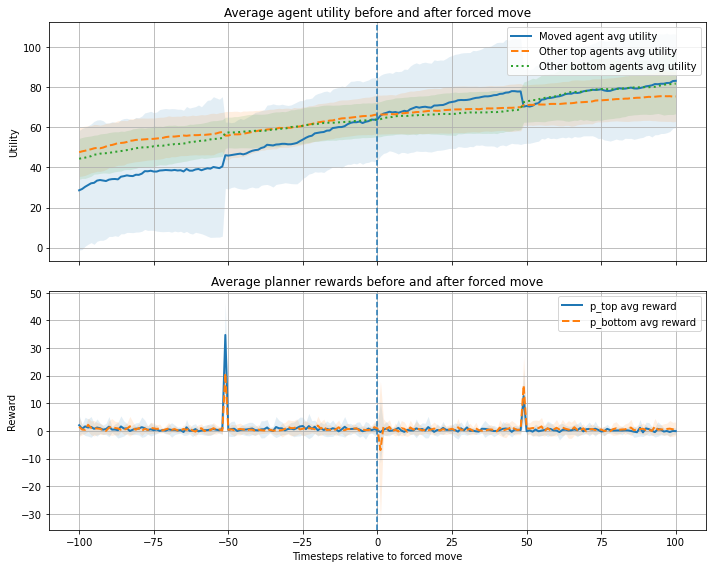

In [217]:
baseline_logs_top_high, forced_logs_top_high = single.generate_paired_baseline_forced_rollout_batch(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    n_rollouts=20,
    forced_agent_id=forced_agent_id,
    forced_timestep=250,
    forced_target_region="bottom",
    forced_move_seed=0,
    explore=False,
    progress=True,
)

fig, summary_df, raw_df = single.plot_forced_move_utilities_system(
    forced_logs_top_high,
    window=100,
)

save_fig(fig, f"plot_forced_move_utilities_system_{forced_agent_id}")

In [ ]:
dense_logs[0]["states"][0]["4"]["build_payment"]
dense_logs[0]["states"][0]["4"]["loc"]


[26, 0]

In [ ]:
dense_logs[0]["states"][0]["0"]["build_payment"]

dense_logs[0]["states"][0]["0"]["loc"]

[0, 0]

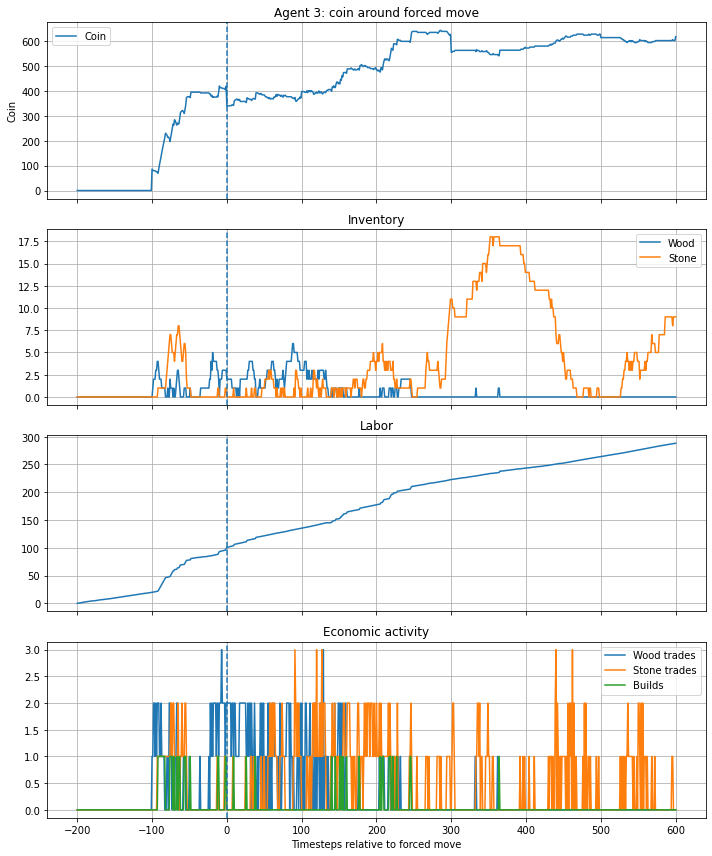

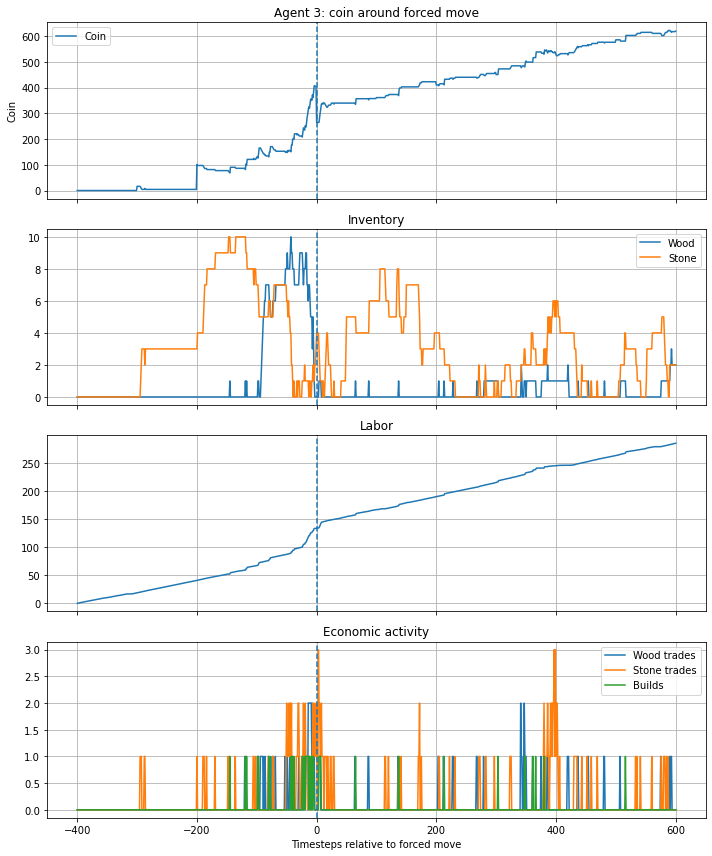

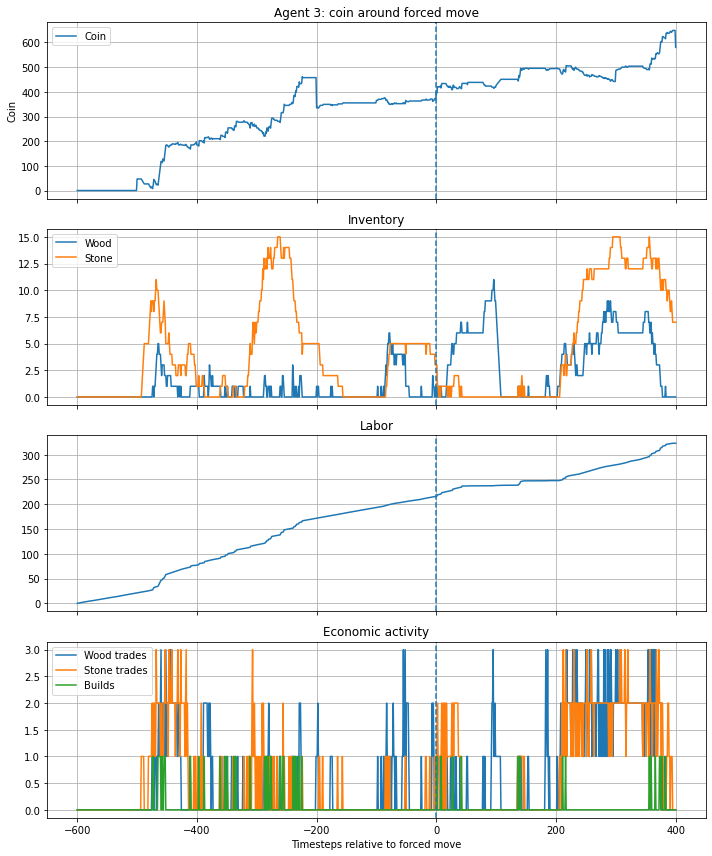

In [ ]:
fig = single.plot_forced_move_timeseries(forced_log_200, window=600)
fig = single.plot_forced_move_timeseries(forced_log_400, window=600)
fig = single.plot_forced_move_timeseries(forced_log_600, window=600)

In [ ]:
df_system = single.forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_system

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1,300,399,99.000,31.54,67.932609,5,110.0,16,-11.0,6,1,3,6,NaN,NaN
1,moved_agent,after_move,1,401,500,47.889,38.98,74.160567,7,154.0,131,-49.0,8,0,63,60,NaN,NaN
2,other_agents,before_move,7,300,399,288.800,183.34,66.787821,16,287.0,220,1.4,29,34,80,77,NaN,NaN
3,other_agents,after_move,7,401,500,239.911,161.99,73.798076,11,163.0,333,41.4,21,29,140,143,NaN,NaN


In [ ]:
# use the same moved agent and timestep as in the forced-move run
moved_agent = forced_log["forced_move"]["agent"]
reference_timestep = forced_log["forced_move"]["timestep"]

df_forced = single.forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_baseline = single.baseline_system_summary_table(
    dense_logs,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=100,
    window_after=100,
)

df_baseline

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1.0,300,399,232.700000,57.22,118.499105,16.0,352.0,51.0,-123.7,15.0,5.0,26.0,5.0,NaN,NaN
1,moved_agent,after_move,1.0,401,500,63.639688,36.18,136.766441,6.0,132.0,47.0,-39.2,5.0,2.0,23.0,17.0,NaN,NaN
2,other_agents,before_move,7.0,300,399,582.000000,203.01,91.414826,27.0,495.0,249.0,113.0,31.0,41.0,78.0,99.0,NaN,NaN
3,other_agents,after_move,7.0,401,500,533.960313,197.49,109.539377,25.0,475.0,209.0,29.4,22.0,25.0,78.0,84.0,NaN,NaN
4,p_top,before_move,NaN,300,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.014411,101.441146
5,p_top,after_move,NaN,401,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632980,63.298021
6,p_bottom,before_move,NaN,300,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.023674,102.367396
7,p_bottom,after_move,NaN,401,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.937699,93.769896


In [ ]:
df_forced_cmp = df_forced.copy()
df_forced_cmp["run_type"] = "forced_move"

df_baseline_cmp = df_baseline.copy()
df_baseline_cmp["run_type"] = "baseline"

df_compare = pd.concat([df_baseline_cmp, df_forced_cmp], ignore_index=True)
df_compare

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward,run_type
0,moved_agent,before_move,1.0,300,399,232.700000,57.22,118.499105,16.0,352.0,51.0,-123.7,15.0,5.0,26.0,5.0,NaN,NaN,baseline
1,moved_agent,after_move,1.0,401,500,63.639688,36.18,136.766441,6.0,132.0,47.0,-39.2,5.0,2.0,23.0,17.0,NaN,NaN,baseline
2,other_agents,before_move,7.0,300,399,582.000000,203.01,91.414826,27.0,495.0,249.0,113.0,31.0,41.0,78.0,99.0,NaN,NaN,baseline
3,other_agents,after_move,7.0,401,500,533.960313,197.49,109.539377,25.0,475.0,209.0,29.4,22.0,25.0,78.0,84.0,NaN,NaN,baseline
4,p_top,before_move,NaN,300,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.014411,101.441146,baseline
5,p_top,after_move,NaN,401,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632980,63.298021,baseline
6,p_bottom,before_move,NaN,300,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.023674,102.367396,baseline
7,p_bottom,after_move,NaN,401,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.937699,93.769896,baseline
8,moved_agent,before_move,1.0,300,399,99.000000,31.54,67.932609,5.0,110.0,16.0,-11.0,6.0,1.0,3.0,6.0,NaN,NaN,forced_move
9,moved_agent,after_move,1.0,401,500,47.889000,38.98,74.160567,7.0,154.0,131.0,-49.0,8.0,0.0,63.0,60.0,NaN,NaN,forced_move


In [ ]:
def forced_move_system_summary_table_no_planner(log, window_before=100, window_after=100):
    """
    Summary table for moved agent, other agents, and both planners
    before vs after a forced move.

    Returns a pandas DataFrame.
    """
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    moved_agent = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out



    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                #"n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,

            })


    return pd.DataFrame(rows)

In [ ]:
def baseline_system_summary_table_no_planner(log, moved_agent, reference_timestep, window_before=100, window_after=100, episode_key=0):

    if "states" in log:
        ep_log = log
    elif episode_key in log and isinstance(log[episode_key], dict) and "states" in log[episode_key]:
        ep_log = log[episode_key]
    else:
        ep_log = None
        for v in log.values():
            if isinstance(v, dict) and "states" in v:
                ep_log = v
                break
        if ep_log is None:
            raise ValueError("Could not find a single episode log with key 'states'.")

    t0 = int(reference_timestep)

    states = ep_log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    if moved_agent not in agent_ids:
        raise ValueError(f"moved_agent={moved_agent} not found in baseline log")

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(ep_log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(ep_log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out

    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                #"n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,
            })

    return pd.DataFrame(rows)


In [ ]:
paired_baseline_log, paired_forced_log = single.generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=400,
    forced_target_region="bottom",
    explore=False,
)

In [ ]:
df_forced = forced_move_system_summary_table_no_planner(
    paired_forced_log,
    window_before=200,
    window_after=200,
)
df_forced["run_type"] = "forced_move"

In [ ]:
moved_agent = paired_forced_log["forced_move"]["agent"]
reference_timestep = paired_forced_log["forced_move"]["timestep"]

df_baseline = baseline_system_summary_table_no_planner(
    paired_baseline_log,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=200,
    window_after=200,
)
df_baseline["run_type"] = "baseline"

In [ ]:
df_compare = pd.concat([df_baseline, df_forced], ignore_index=True)
df_compare

,group,period,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,run_type
0,moved_agent,before_move,200,399,191.349688,43.90,73.763917,0,0.0,61,227.6,3,38,3,17,baseline
1,moved_agent,after_move,401,600,119.889375,43.36,119.016931,0,0.0,53,155.4,8,36,0,9,baseline
2,other_agents,before_move,200,399,1350.350312,443.97,76.615501,78,1566.0,585,-251.9,117,82,200,186,baseline
3,other_agents,after_move,401,600,629.210625,363.69,104.924876,38,788.0,507,-194.3,186,158,86,77,baseline
4,moved_agent,before_move,200,399,191.349688,43.90,73.763917,0,0.0,61,227.6,3,38,3,17,forced_move
5,moved_agent,after_move,401,600,65.076500,29.96,103.364013,2,22.0,49,-11.0,5,4,20,20,forced_move
6,other_agents,before_move,200,399,1350.350312,443.97,76.615501,78,1566.0,585,-251.9,117,82,200,186,forced_move
7,other_agents,after_move,401,600,900.423500,355.44,109.528142,51,996.0,509,-42.5,113,114,141,141,forced_move


,t,relative_t,moved_agent_utility,other_top_agents_avg_utility,other_bottom_agents_avg_utility,p_top_reward,p_bottom_reward
0,0,-400,-1.342801,-1.377976,-1.364501,0.0,0.0
1,1,-399,-1.386901,-1.448851,-1.426801,0.0,0.0
2,2,-398,-1.441501,-1.533901,-1.477901,0.0,0.0
3,3,-397,-1.506601,-1.599526,-1.510801,0.0,0.0
4,4,-396,-1.550701,-1.651501,-1.554901,0.0,0.0


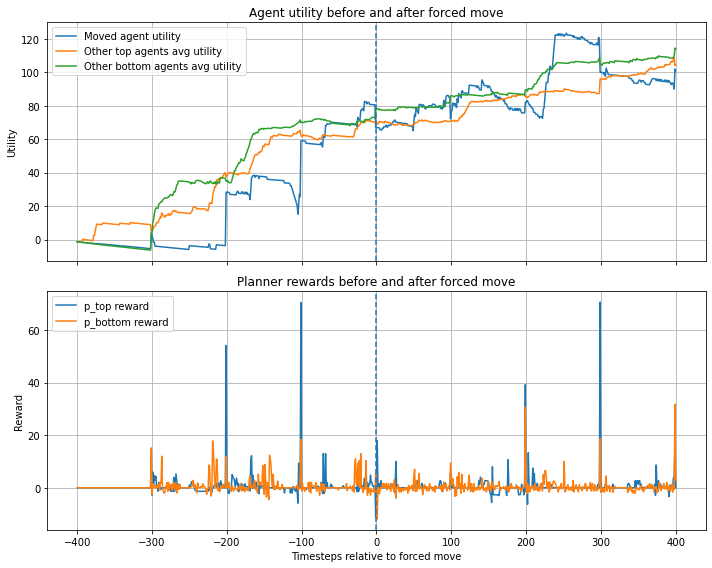

In [ ]:
fig, df_util = single.plot_forced_move_utilities_system(forced_log, window=400)
df_util.head()

In [ ]:
df_delta = single.forced_move_delta_table(forced_log, window_before=100, window_after=100)
df_delta

,group,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,0,101,101,-51.111,7.44,6.227957,2,44.0,115,-38.0,2,-1,60,54,NaN,NaN
1,other_agents,0,101,101,-48.889,-21.35,7.010255,-5,-124.0,113,40.0,-8,-5,60,66,NaN,NaN
